<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/DRAM_vs_SRAM_32_64_96_128GiB_Aug2026_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# DRAM versus SRAM at 32, 64, 96, and 128 GiB — August 2026

## Motivation

Replacing commodity DRAM with discrete SRAM at workstation-scale
capacities exposes a sharp trade space between random-access latency,
capacity density, package count, electrical power, physical board area,
and raw component cost. The comparison becomes especially informative
above 32 GiB, where thousands of SRAM packages are required even with
the highest-density monolithic SRAMs available in commercial catalogs.

This notebook uses an **August 28, 2026 price snapshot** and scales three
representative discrete SRAM implementations to **32, 64, 96, and
128 GiB**:

1. **GSI 288 Mbit standard synchronous SRAM at 250 MHz**, selected as a
   density-oriented and lower-cost case.
2. **Infineon 144 Mbit QDR-IV HP SRAM at 633 MHz**, selected as a
   high-random-transaction-rate case.
3. **GSI 288 Mbit SigmaQuad-IIIe SRAM at 675 MHz**, selected as a
   high-density, high-bandwidth SRAM case.

Matching Corsair DDR5-5600 CL40 kits provide the DRAM cost baseline.
Retail products use the label `GB`; chip-count arithmetic here treats
each advertised binary memory capacity as GiB so that the bit accounting
stays internally consistent.

The raw SRAM totals are **engineering extrapolations from listed
distributor price tiers**. They exclude negotiated volume pricing,
tariffs, PCB fabrication, assembly, controllers, clock distribution,
voltage regulation, connectors, cooling, yield loss, test, and system
integration. The resulting figures should be interpreted as component
scale estimates instead of procurement quotations.

## Notation and Symbols

| Symbol | Definition | Units |
| :--- | :--- | :---: |
| $C$ | Target memory capacity | GiB |
| $C_{\mathrm{MiB}}$ | Target capacity expressed in MiB | MiB |
| $D$ | SRAM package density | Mbit |
| $D_{\mathrm{MiB}}$ | SRAM package density expressed in MiB | MiB |
| $N$ | Required SRAM package count | packages |
| $p$ | Listed SRAM price per package | USD/package |
| $P_{\mathrm{raw}}$ | Extrapolated raw SRAM IC cost | USD |
| $A_{\mathrm{pkg}}$ | Package plan-view area | $\mathrm{mm^2}$ |
| $A_{\mathrm{tot}}$ | Sum of SRAM package plan-view areas | $\mathrm{m^2}$ |
| $A_{\mathrm{DIMM}}$ | Nominal DDR5 UDIMM PCB face area | $\mathrm{mm^2}$ |
| $f_{\mathrm{CK}}$ | Memory clock frequency | MHz |
| $R_{\mathrm{data}}$ | DDR5 transfer rate | MT/s |
| $L$ | Read latency | clock cycles |
| $t_{\mathrm{read}}$ | Device read latency | ns |
| $B$ | Peak external data bandwidth | GB/s |
| $I_{\mathrm{DD}}$ | Core operating current | A |
| $V_{\mathrm{DD}}$ | Core supply voltage | V |
| $P_{\mathrm{core}}$ | Estimated SRAM core power | W |

## Architecture Primer

Commodity DRAM achieves very high density with a one-transistor,
one-capacitor storage cell. Charge leakage requires periodic refresh,
and accesses are mediated by row activation, sense amplifiers, row
buffers, and precharge operations.

SRAM stores state in a bistable transistor network, commonly represented
by the six-transistor SRAM cell. The stored logic level persists as long
as supply power is present, so refresh cycles disappear. High-performance
synchronous SRAM packages add substantial peripheral circuitry for
pipelining, I/O timing, termination, ECC, address handling, and interface
training.

At workstation capacities, the memory-cell advantage in access regularity
collides with SRAM's much lower bit density. Large-capacity discrete SRAM
consequently resembles a multi-board memory appliance more than a DIMM.

### Memory hierarchy connection

```text
Processor memory hierarchy
│
├── Registers
│   └── Smallest capacity, shortest access path
│
├── On-chip SRAM caches
│   ├── L1
│   ├── L2
│   └── L3 / LLC
│
├── Hypothetical external bulk SRAM
│   ├── Excellent random-access regularity
│   ├── Thousands of packages at 32–128 GiB
│   ├── Multi-kilowatt core-power scale
│   └── Hundreds of thousands to millions of dollars in raw ICs
│
└── DRAM main memory
    ├── Much greater bit density
    ├── Refresh and row-management overhead
    └── Tens to hundreds of GiB in practical DIMM form factors
```

In [17]:
"""Configure the August 2026 DRAM-versus-SRAM comparison."""

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

SNAPSHOT_DATE = "2026-08-28"

TARGET_CAPACITIES_GIB = np.array([32, 64, 96, 128], dtype=int)

FIGURE_DPI = 250
EXPORT_CSV = True
EXPORT_DIRECTORY = Path("/content")

# A value of 1.0 counts package rectangles only.
# Increase this factor to explore routing/clearance overhead.
PCB_AREA_MULTIPLIER = 1.0

DDR5_DATA_RATE_MT_S = 5600.0
DDR5_BUS_WIDTH_BITS = 64
DDR5_CL = 40.0
DDR5_TRCD = 40.0
DDR5_TRP = 40.0

DDR5_UDIMM_LENGTH_MM = 133.35
DDR5_UDIMM_HEIGHT_MM = 31.25

DRAM_ROWS = [
    {
        "capacity_gib": 32,
        "product": "Corsair VENGEANCE 1x32 GB",
        "price_usd": 478.99,
        "data_rate_mt_s": 5600,
        "cl": 40,
        "status": "In stock in snapshot",
    },
    {
        "capacity_gib": 64,
        "product": "Corsair VENGEANCE 2x32 GB",
        "price_usd": 956.99,
        "data_rate_mt_s": 5600,
        "cl": 40,
        "status": "In stock in snapshot",
    },
    {
        "capacity_gib": 96,
        "product": "Corsair VENGEANCE 2x48 GB",
        "price_usd": 1366.99,
        "data_rate_mt_s": 5600,
        "cl": 40,
        "status": "In stock in snapshot",
    },
    {
        "capacity_gib": 128,
        "product": "Corsair VENGEANCE 4x32 GB",
        "price_usd": 2456.99,
        "data_rate_mt_s": 5600,
        "cl": 40,
        "status": "Displayed price; out of stock",
    },
]

SRAM_PARTS = [
    {
        "short_name": "GSI 288 Mbit Sync 250",
        "manufacturer": "GSI Technology",
        "part_number": "GS8256436GB-250I",
        "architecture": "Standard synchronous SRAM",
        "density_mbit": 288.0,
        "price_usd": 460.46,
        "price_tier": "10-unit listed tier",
        "clock_mhz": 250.0,
        "data_width_bits": 36,
        "read_latency_cycles": np.nan,
        "peak_bandwidth_gb_s": 1.125,
        "package_length_mm": 22.0,
        "package_width_mm": 14.0,
        "core_current_a": np.nan,
        "core_voltage_v": np.nan,
        "power_basis": "Power omitted: no common basis used here",
    },
    {
        "short_name": "Infineon 144 Mbit QDR-IV 633",
        "manufacturer": "Infineon",
        "part_number": "CY7C4121KV13-633FCXI",
        "architecture": "QDR-IV HP, dual bidirectional DDR ports",
        "density_mbit": 144.0,
        "price_usd": 360.021,
        "price_tier": "120-unit listed tier",
        "clock_mhz": 633.0,
        "data_width_bits": 18,
        "read_latency_cycles": 5.0,
        "peak_bandwidth_gb_s": 5.697,
        "package_length_mm": 21.0,
        "package_width_mm": 21.0,
        "core_current_a": 1.655,
        "core_voltage_v": 1.3,
        "power_basis": "Typical core IDD at 633 MHz x18",
    },
    {
        "short_name": "GSI 288 Mbit SigmaQuad 675",
        "manufacturer": "GSI Technology",
        "part_number": "GS82583ED36GK-675I",
        "architecture": "SigmaQuad-IIIe B4, separate DDR I/O",
        "density_mbit": 288.0,
        "price_usd": 773.08,
        "price_tier": "10-unit listed tier",
        "clock_mhz": 675.0,
        "data_width_bits": 36,
        "read_latency_cycles": 3.0,
        "peak_bandwidth_gb_s": 97.0 / 8.0,
        "package_length_mm": 22.0,
        "package_width_mm": 14.0,
        "core_current_a": 1.780,
        "core_voltage_v": 1.3,
        "power_basis": "Datasheet operating IDD at 675 MHz x36",
    },
]

mpl.rcParams["figure.dpi"] = FIGURE_DPI
mpl.rcParams["savefig.dpi"] = FIGURE_DPI
mpl.rcParams["axes.grid"] = True
mpl.rcParams["grid.alpha"] = 0.25

## First-Principles Scaling

A marketed target capacity $C$ in GiB contains

$$
C_{\mathrm{MiB}} = 1024C.
$$

An SRAM package with density $D$ Mbit contains

$$
D_{\mathrm{MiB}} = \frac{D}{8}.
$$

The package count must be an integer, so

$$
N =
\left\lceil
\frac{1024C}{D/8}
\right\rceil.
$$

Raw memory-IC cost follows

$$
P_{\mathrm{raw}} = Np.
$$

Summing package rectangles gives the physical lower bound

$$
A_{\mathrm{tot}}
=
N A_{\mathrm{pkg}}.
$$

This area is optimistic. Real routing, power delivery, decoupling,
connectors, controller devices, keepouts, and thermal hardware add
board area.

Device latency derived from a synchronous clock is

$$
t_{\mathrm{read}}
=
\frac{L}{f_{\mathrm{CK}}}.
$$

For DDR5-5600, the command clock is

$$
f_{\mathrm{CK,DDR5}}
=
\frac{5600}{2}
=
2800\ \mathrm{MHz}.
$$

With CL40,

$$
t_{\mathrm{CL}}
=
\frac{40}{2800\ \mathrm{MHz}}
\approx
14.29\ \mathrm{ns}.
$$

A simplified closed-row path using $t_{\mathrm{RCD}}+t_{\mathrm{CL}}$
gives about $28.57$ ns, and a simplified row-conflict path using
$t_{\mathrm{RP}}+t_{\mathrm{RCD}}+t_{\mathrm{CL}}$ gives about
$42.86$ ns.

Peak DDR5 module bandwidth for a 64-bit data interface is

$$
B_{\mathrm{DDR5}}
=
5600\times10^6
\frac{\mathrm{transfers}}{\mathrm{s}}
\frac{64}{8}
=
44.8\ \mathrm{GB/s}.
$$

In [18]:
"""Build normalized DRAM and SRAM comparison tables."""


def package_count(capacity_gib: float, density_mbit: float) -> int:
    """Return the integer package count for a binary GiB target."""
    target_mib = capacity_gib * 1024.0
    package_mib = density_mbit / 8.0
    return math.ceil(target_mib / package_mib)


def build_sram_table(
    capacities_gib: np.ndarray,
    parts: list[dict[str, object]],
    dram_df: pd.DataFrame,
) -> pd.DataFrame:
    """Scale each SRAM part to every requested capacity."""
    rows: list[dict[str, object]] = []

    dram_prices = dram_df.set_index("capacity_gib")["price_usd"]

    for part in parts:
        density_mib = float(part["density_mbit"]) / 8.0
        package_area_mm2 = (
            float(part["package_length_mm"])
            * float(part["package_width_mm"])
        )

        for capacity_gib in capacities_gib:
            count = package_count(
                float(capacity_gib),
                float(part["density_mbit"]),
            )
            installed_mib = count * density_mib
            raw_cost = count * float(part["price_usd"])
            ideal_area_m2 = (
                count
                * package_area_mm2
                * PCB_AREA_MULTIPLIER
                / 1e6
            )

            latency_cycles = float(part["read_latency_cycles"])
            if np.isfinite(latency_cycles):
                latency_ns = (
                    latency_cycles
                    * 1000.0
                    / float(part["clock_mhz"])
                )
            else:
                latency_ns = np.nan

            core_current_a = float(part["core_current_a"])
            core_voltage_v = float(part["core_voltage_v"])
            if (
                np.isfinite(core_current_a)
                and np.isfinite(core_voltage_v)
            ):
                core_power_kw = (
                    count
                    * core_current_a
                    * core_voltage_v
                    / 1000.0
                )
            else:
                core_power_kw = np.nan

            rows.append(
                {
                    "capacity_gib": int(capacity_gib),
                    "sram": part["short_name"],
                    "part_number": part["part_number"],
                    "architecture": part["architecture"],
                    "density_mbit": float(part["density_mbit"]),
                    "package_count": count,
                    "installed_gib": installed_mib / 1024.0,
                    "capacity_overhead_mib": (
                        installed_mib
                        - float(capacity_gib) * 1024.0
                    ),
                    "unit_price_usd": float(part["price_usd"]),
                    "price_tier": part["price_tier"],
                    "raw_ic_cost_usd": raw_cost,
                    "cost_per_gib_usd": (
                        raw_cost / float(capacity_gib)
                    ),
                    "dram_price_usd": float(
                        dram_prices.loc[int(capacity_gib)]
                    ),
                    "cost_multiplier_vs_dram": (
                        raw_cost
                        / float(dram_prices.loc[int(capacity_gib)])
                    ),
                    "ideal_package_area_m2": ideal_area_m2,
                    "read_latency_ns": latency_ns,
                    "per_package_bandwidth_gb_s": float(
                        part["peak_bandwidth_gb_s"]
                    ),
                    "pin_level_sum_bandwidth_tb_s": (
                        count
                        * float(part["peak_bandwidth_gb_s"])
                        / 1000.0
                    ),
                    "estimated_core_power_kw": core_power_kw,
                    "power_basis": part["power_basis"],
                }
            )

    return pd.DataFrame(rows)


dram_df = pd.DataFrame(DRAM_ROWS)
dram_df["cost_per_gib_usd"] = (
    dram_df["price_usd"] / dram_df["capacity_gib"]
)

sram_parts_df = pd.DataFrame(SRAM_PARTS)
sram_df = build_sram_table(
    TARGET_CAPACITIES_GIB,
    SRAM_PARTS,
    dram_df,
)

ddr5_clock_mhz = DDR5_DATA_RATE_MT_S / 2.0
ddr5_cas_ns = DDR5_CL * 1000.0 / ddr5_clock_mhz
ddr5_closed_row_ns = (
    DDR5_TRCD + DDR5_CL
) * 1000.0 / ddr5_clock_mhz
ddr5_row_conflict_ns = (
    DDR5_TRP + DDR5_TRCD + DDR5_CL
) * 1000.0 / ddr5_clock_mhz
ddr5_bandwidth_gb_s = (
    DDR5_DATA_RATE_MT_S
    * DDR5_BUS_WIDTH_BITS
    / 8.0
    / 1000.0
)

dimm_face_area_mm2 = (
    DDR5_UDIMM_LENGTH_MM * DDR5_UDIMM_HEIGHT_MM
)
sram_df["dimm_face_area_equivalents"] = (
    sram_df["ideal_package_area_m2"] * 1e6
    / dimm_face_area_mm2
)

print(f"Price snapshot: {SNAPSHOT_DATE}")
print(f"DDR5-5600 theoretical 64-bit bandwidth: "
      f"{ddr5_bandwidth_gb_s:.1f} GB/s")
print(f"DDR5-5600 CL40 CAS timing: {ddr5_cas_ns:.2f} ns")

Price snapshot: 2026-08-28
DDR5-5600 theoretical 64-bit bandwidth: 44.8 GB/s
DDR5-5600 CL40 CAS timing: 14.29 ns


## Input Data Tables

In [19]:
"""Display the source-level DRAM and SRAM inputs."""

display(
    dram_df[
        [
            "capacity_gib",
            "product",
            "price_usd",
            "data_rate_mt_s",
            "cl",
            "cost_per_gib_usd",
            "status",
        ]
    ].round(3)
)

display(
    sram_parts_df[
        [
            "short_name",
            "part_number",
            "architecture",
            "density_mbit",
            "price_usd",
            "price_tier",
            "clock_mhz",
            "data_width_bits",
            "read_latency_cycles",
            "peak_bandwidth_gb_s",
            "package_length_mm",
            "package_width_mm",
        ]
    ].round(3)
)

,capacity_gib,product,price_usd,data_rate_mt_s,cl,cost_per_gib_usd,status
0,32,Corsair VENGEANCE 1x32 GB,478.99,5600,40,14.968,In stock in snapshot
1,64,Corsair VENGEANCE 2x32 GB,956.99,5600,40,14.953,In stock in snapshot
2,96,Corsair VENGEANCE 2x48 GB,1366.99,5600,40,14.239,In stock in snapshot
3,128,Corsair VENGEANCE 4x32 GB,2456.99,5600,40,19.195,Displayed price; out of stock


,short_name,part_number,architecture,density_mbit,price_usd,price_tier,clock_mhz,data_width_bits,read_latency_cycles,peak_bandwidth_gb_s,package_length_mm,package_width_mm
0,GSI 288 Mbit Sync 250,GS8256436GB-250I,Standard synchronous SRAM,288.0,460.460,10-unit listed tier,250.0,36,NaN,1.125,22.0,14.0
1,Infineon 144 Mbit QDR-IV 633,CY7C4121KV13-633FCXI,"QDR-IV HP, dual bidirectional DDR ports",144.0,360.021,120-unit listed tier,633.0,18,5.0,5.697,21.0,21.0
2,GSI 288 Mbit SigmaQuad 675,GS82583ED36GK-675I,"SigmaQuad-IIIe B4, separate DDR I/O",288.0,773.080,10-unit listed tier,675.0,36,3.0,12.125,22.0,14.0


## Capacity-Scaled Results

In [20]:
"""Display the complete capacity-scaled SRAM result table."""

result_columns = [
    "capacity_gib",
    "sram",
    "package_count",
    "installed_gib",
    "capacity_overhead_mib",
    "raw_ic_cost_usd",
    "cost_per_gib_usd",
    "dram_price_usd",
    "cost_multiplier_vs_dram",
    "ideal_package_area_m2",
    "dimm_face_area_equivalents",
    "read_latency_ns",
    "per_package_bandwidth_gb_s",
    "pin_level_sum_bandwidth_tb_s",
    "estimated_core_power_kw",
]

display(
    sram_df[result_columns]
    .sort_values(["capacity_gib", "raw_ic_cost_usd"])
    .round(3)
    .reset_index(drop=True)
)

,capacity_gib,sram,package_count,installed_gib,capacity_overhead_mib,raw_ic_cost_usd,cost_per_gib_usd,dram_price_usd,cost_multiplier_vs_dram,ideal_package_area_m2,dimm_face_area_equivalents,read_latency_ns,per_package_bandwidth_gb_s,pin_level_sum_bandwidth_tb_s,estimated_core_power_kw
0,32,GSI 288 Mbit Sync 250,911,32.027,28.0,419479.060,13108.721,478.99,875.757,0.281,67.333,NaN,1.125,1.025,NaN
1,32,Infineon 144 Mbit QDR-IV 633,1821,32.010,10.0,655598.241,20487.445,478.99,1368.710,0.803,192.711,7.899,5.697,10.374,3.918
2,32,GSI 288 Mbit SigmaQuad 675,911,32.027,28.0,704275.880,22008.621,478.99,1470.335,0.281,67.333,4.444,12.125,11.046,2.108
3,64,GSI 288 Mbit Sync 250,1821,64.020,20.0,838497.660,13101.526,956.99,876.182,0.561,134.591,NaN,1.125,2.049,NaN
4,64,Infineon 144 Mbit QDR-IV 633,3641,64.002,2.0,1310836.461,20481.820,956.99,1369.749,1.606,385.315,7.899,5.697,20.743,7.834
5,64,GSI 288 Mbit SigmaQuad 675,1821,64.020,20.0,1407778.680,21996.542,956.99,1471.048,0.561,134.591,4.444,12.125,22.080,4.214
6,96,GSI 288 Mbit Sync 250,2731,96.012,12.0,1257516.260,13099.128,1366.99,919.916,0.841,201.850,NaN,1.125,3.072,NaN
7,96,Infineon 144 Mbit QDR-IV 633,5462,96.012,12.0,1966434.702,20483.695,1366.99,1438.514,2.409,578.026,7.899,5.697,31.117,11.751
8,96,GSI 288 Mbit SigmaQuad 675,2731,96.012,12.0,2111281.480,21992.515,1366.99,1544.475,0.841,201.850,4.444,12.125,33.113,6.320
9,128,GSI 288 Mbit Sync 250,3641,128.004,4.0,1676534.860,13097.929,2456.99,682.353,1.121,269.109,NaN,1.125,4.096,NaN


## Compact Cost Table

The following pivot places the cost numbers most relevant to the
64, 96, and 128 GiB question side-by-side.

In [21]:
"""Create a compact cross-technology cost table."""

sram_cost_pivot = (
    sram_df.pivot(
        index="capacity_gib",
        columns="sram",
        values="raw_ic_cost_usd",
    )
    .reset_index()
)

compact_cost_df = dram_df[
    ["capacity_gib", "price_usd"]
].rename(columns={"price_usd": "DDR5 retail kit USD"})

compact_cost_df = compact_cost_df.merge(
    sram_cost_pivot,
    on="capacity_gib",
    how="left",
)

display(compact_cost_df.round(2))

,capacity_gib,DDR5 retail kit USD,GSI 288 Mbit SigmaQuad 675,GSI 288 Mbit Sync 250,Infineon 144 Mbit QDR-IV 633
0,32,478.99,704275.88,419479.06,655598.24
1,64,956.99,1407778.68,838497.66,1310836.46
2,96,1366.99,2111281.48,1257516.26,1966434.70
3,128,2456.99,2814784.28,1676534.86,2621672.92


## Total Raw Memory Cost

A logarithmic vertical axis keeps the commodity DRAM and discrete SRAM
regimes visible in the same figure.

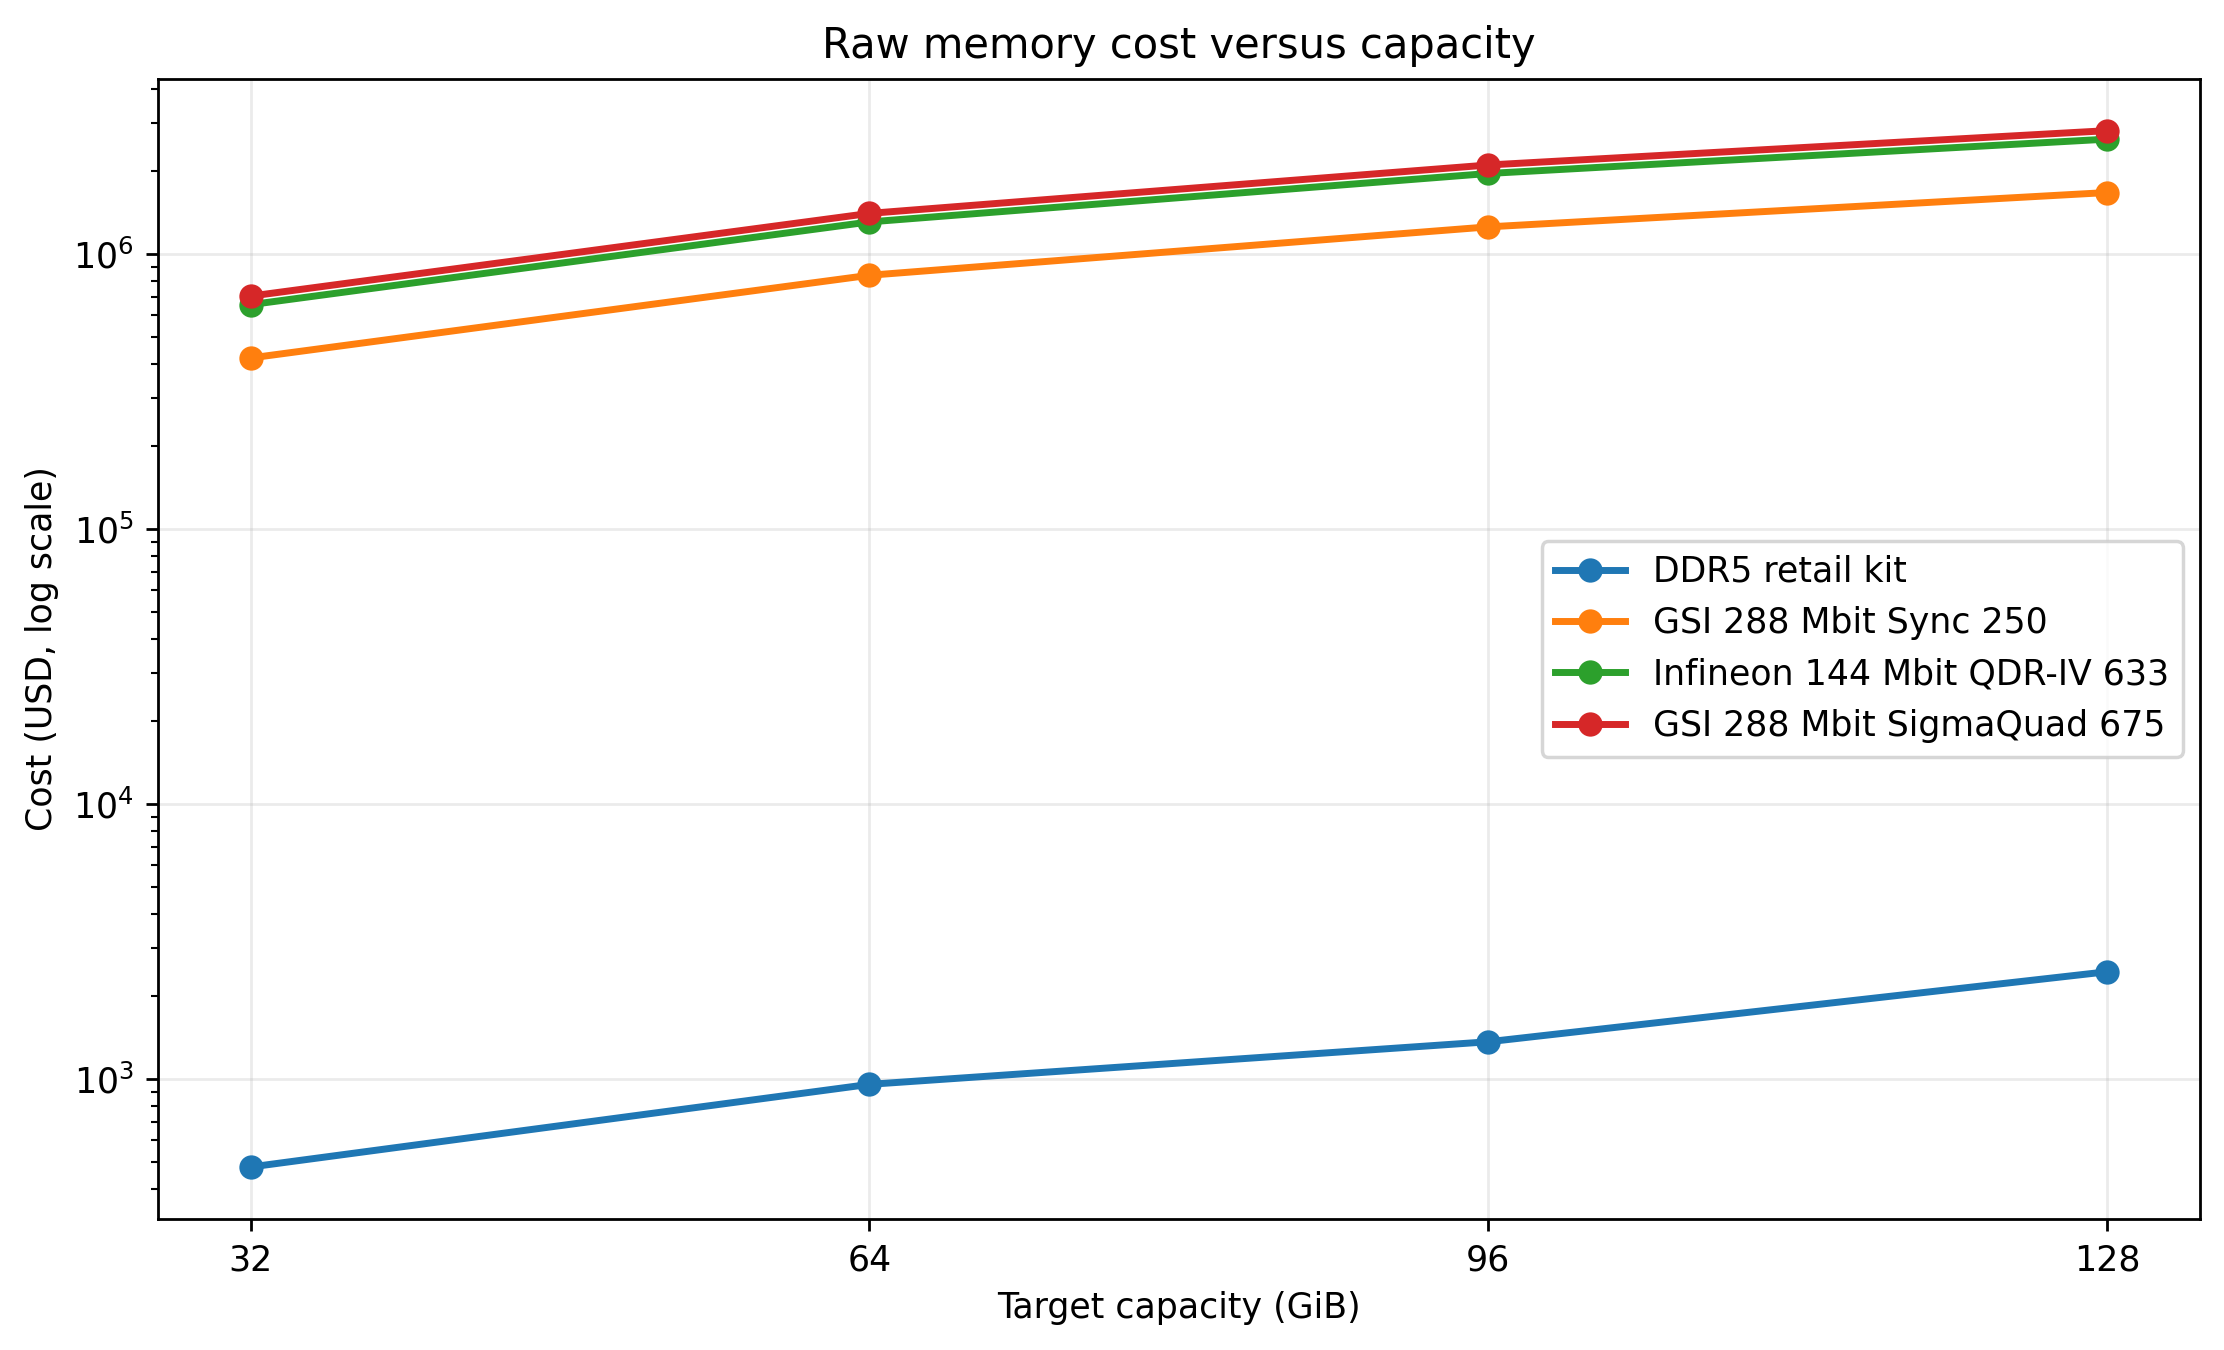

In [22]:
"""Plot total memory cost versus target capacity."""

fig, ax = plt.subplots(figsize=(9.0, 5.5))

ax.plot(
    dram_df["capacity_gib"],
    dram_df["price_usd"],
    marker="o",
    linewidth=2,
    label="DDR5 retail kit",
)

for sram_name, group in sram_df.groupby("sram", sort=False):
    ax.plot(
        group["capacity_gib"],
        group["raw_ic_cost_usd"],
        marker="o",
        linewidth=2,
        label=sram_name,
    )

ax.set_yscale("log")
ax.set_xlabel("Target capacity (GiB)")
ax.set_ylabel("Cost (USD, log scale)")
ax.set_title("Raw memory cost versus capacity")
ax.set_xticks(TARGET_CAPACITIES_GIB)
ax.legend()
fig.tight_layout()
plt.show()

## Cost per GiB

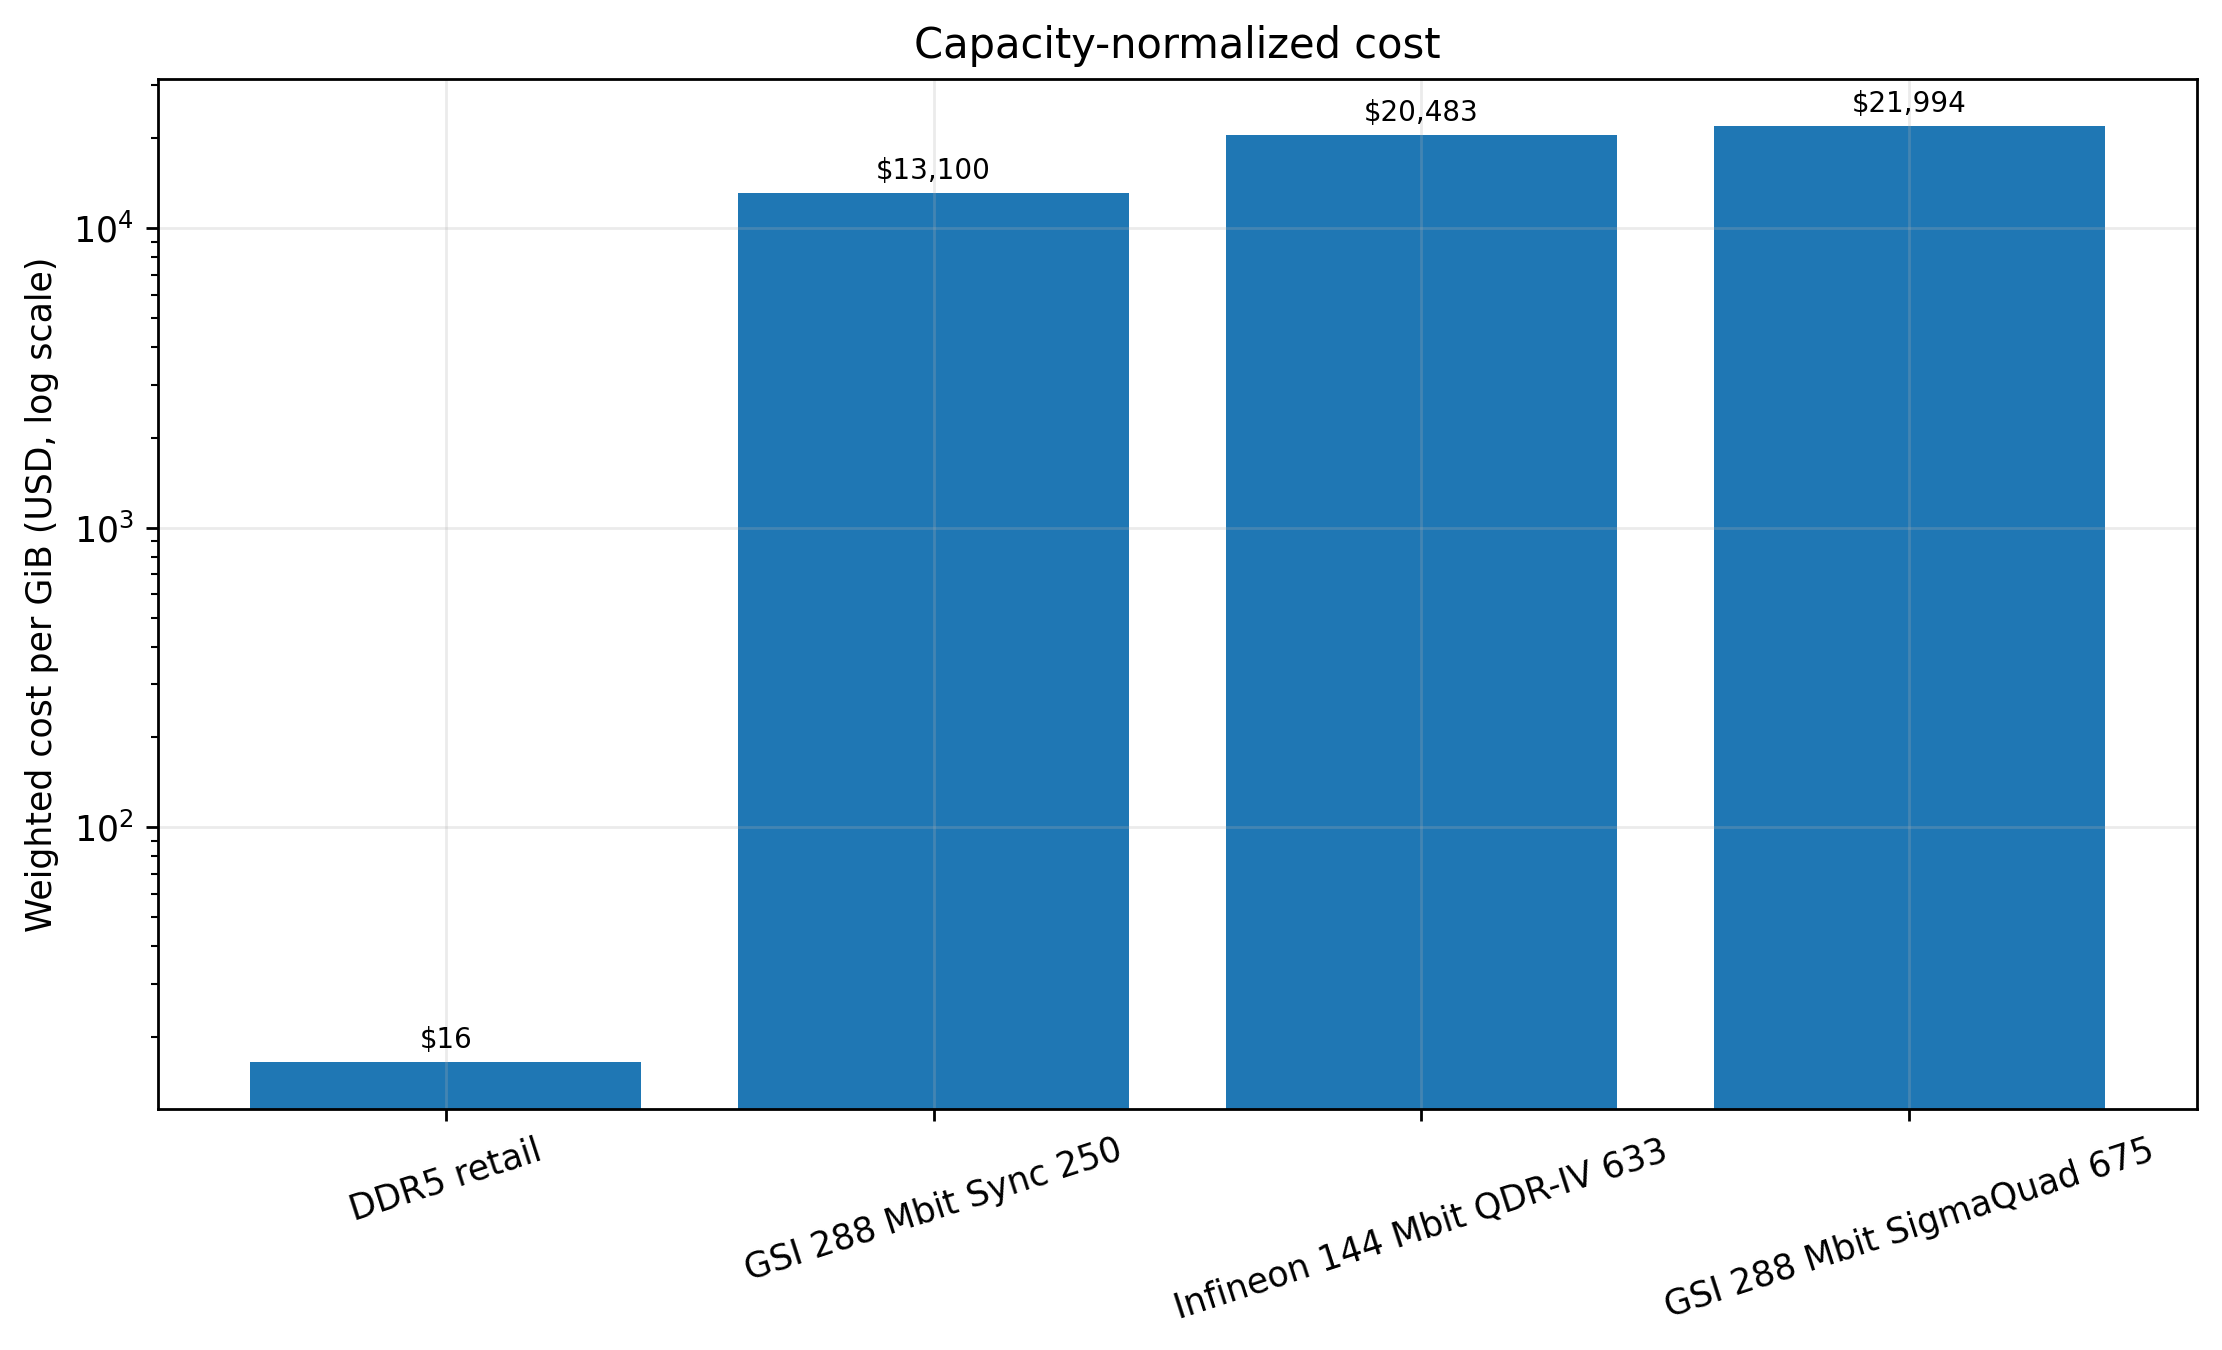

In [23]:
"""Plot capacity-normalized cost."""

cost_per_gib_rows = [
    {
        "technology": "DDR5 retail",
        "cost_per_gib_usd": dram_df["price_usd"].sum()
        / dram_df["capacity_gib"].sum(),
    }
]

for sram_name, group in sram_df.groupby("sram", sort=False):
    cost_per_gib_rows.append(
        {
            "technology": sram_name,
            "cost_per_gib_usd": (
                group["raw_ic_cost_usd"].sum()
                / group["capacity_gib"].sum()
            ),
        }
    )

cost_per_gib_df = pd.DataFrame(cost_per_gib_rows)

fig, ax = plt.subplots(figsize=(9.0, 5.5))
bars = ax.bar(
    cost_per_gib_df["technology"],
    cost_per_gib_df["cost_per_gib_usd"],
)
ax.set_yscale("log")
ax.set_ylabel("Weighted cost per GiB (USD, log scale)")
ax.set_title("Capacity-normalized cost")
ax.tick_params(axis="x", rotation=18)

for bar, value in zip(
    bars,
    cost_per_gib_df["cost_per_gib_usd"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        value * 1.06,
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()
plt.show()

## SRAM Package Count

Doubling SRAM density from 144 Mbit to 288 Mbit nearly halves the
package count. Integer rounding introduces a few extra packages.

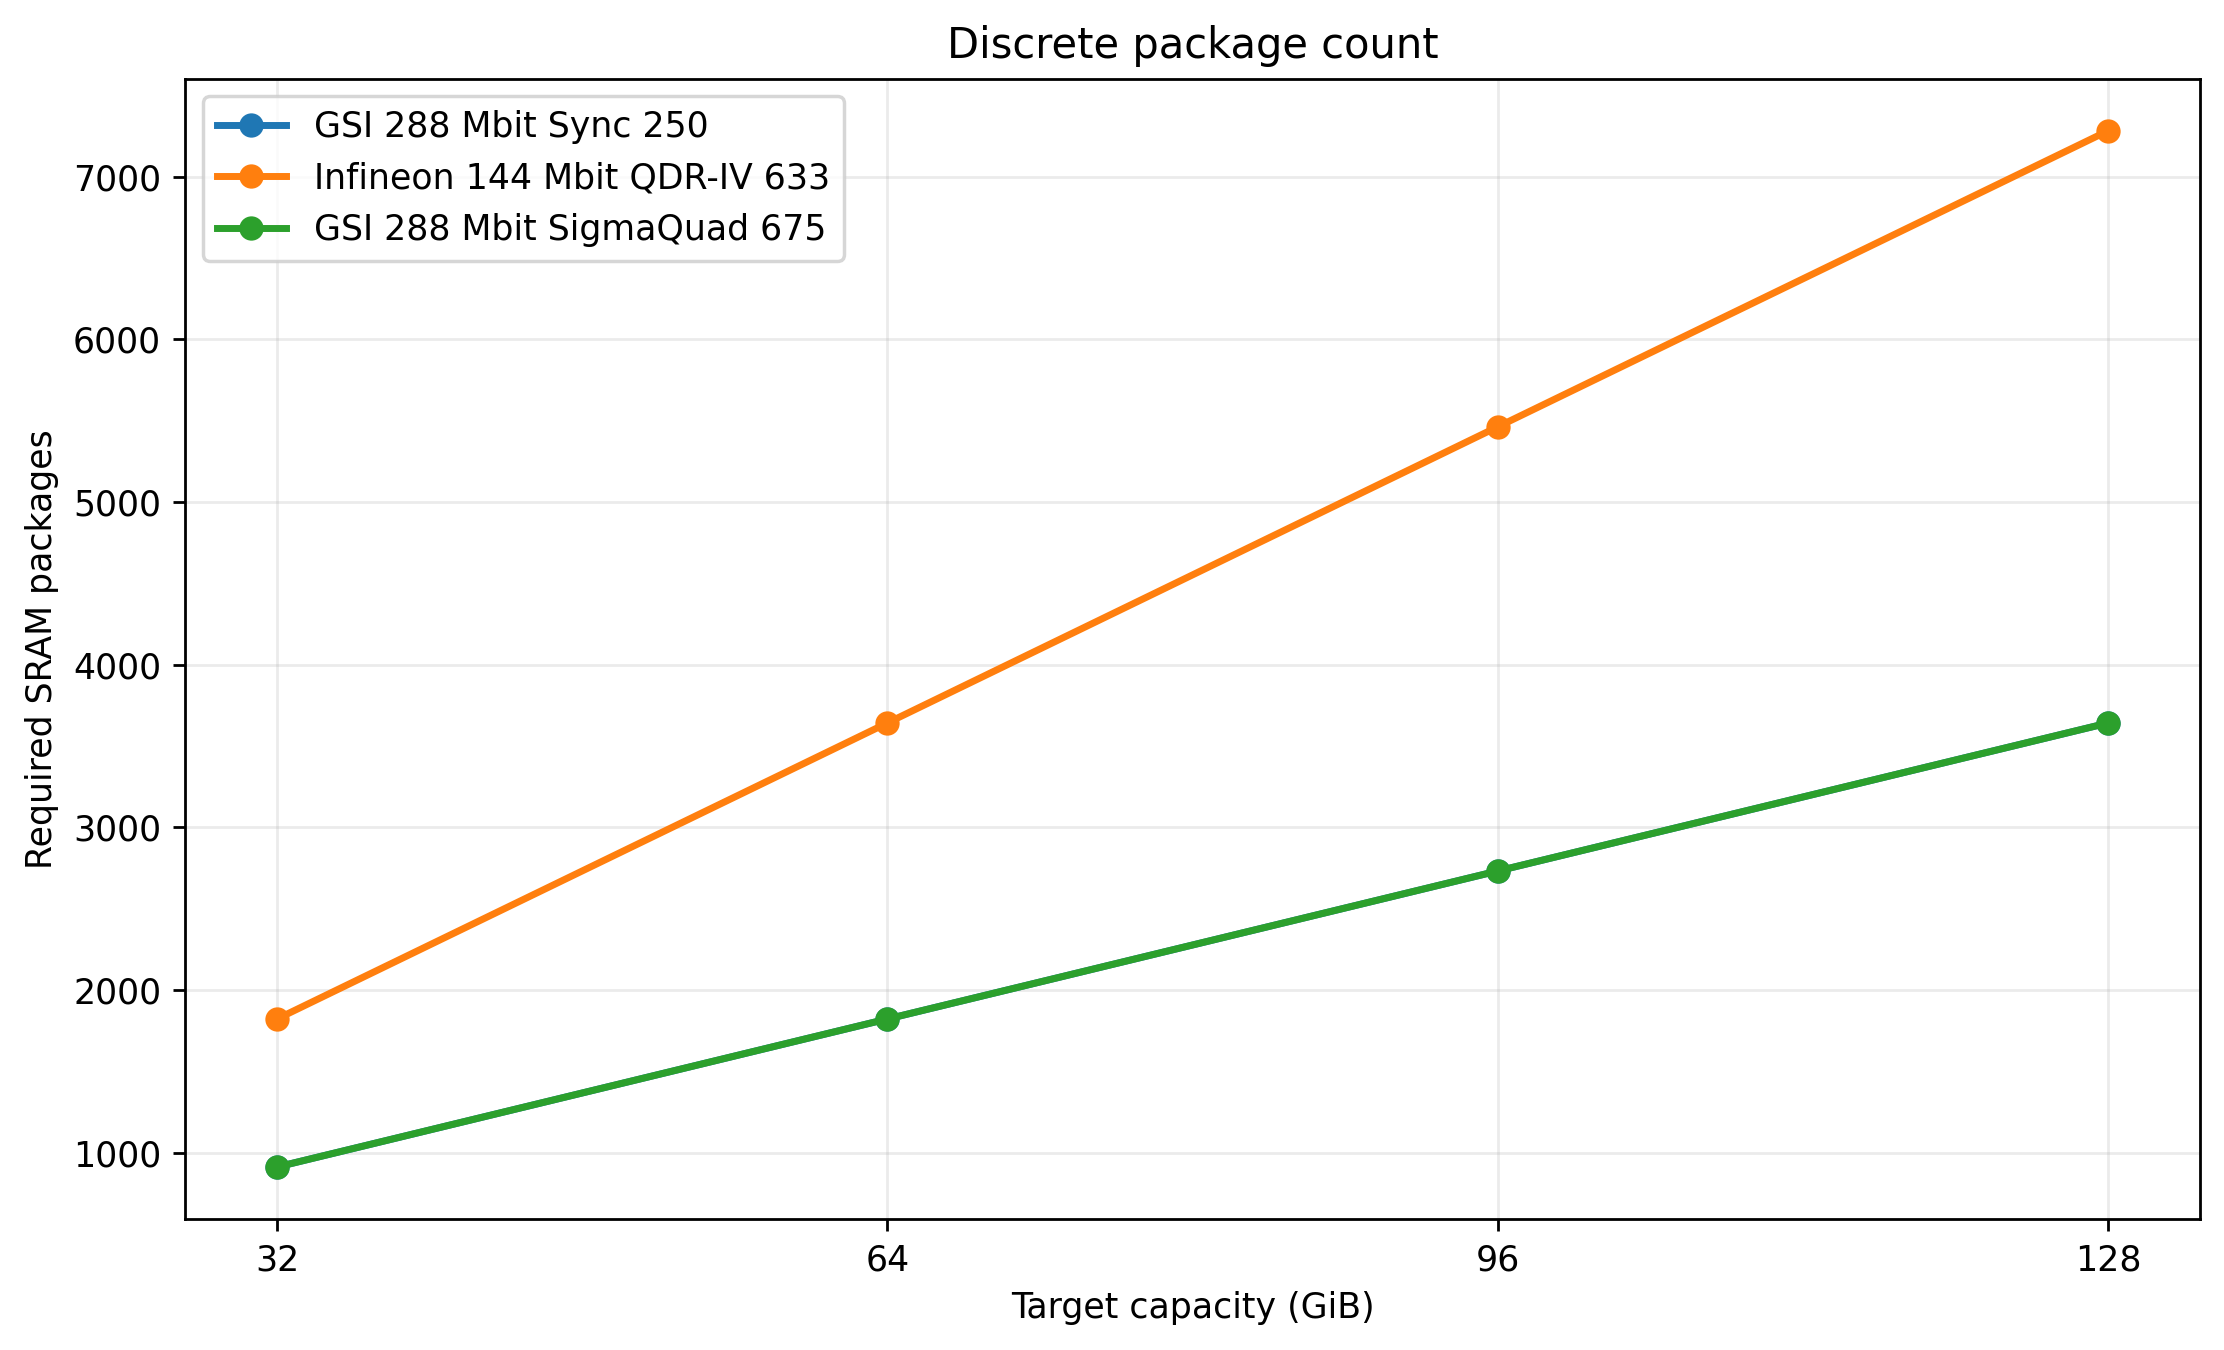

In [24]:
"""Plot discrete SRAM package count versus capacity."""

fig, ax = plt.subplots(figsize=(9.0, 5.5))

for sram_name, group in sram_df.groupby("sram", sort=False):
    ax.plot(
        group["capacity_gib"],
        group["package_count"],
        marker="o",
        linewidth=2,
        label=sram_name,
    )

ax.set_xlabel("Target capacity (GiB)")
ax.set_ylabel("Required SRAM packages")
ax.set_title("Discrete package count")
ax.set_xticks(TARGET_CAPACITIES_GIB)
ax.legend()
fig.tight_layout()
plt.show()

## Package Footprint

This figure counts only the package rectangles. A real memory subsystem
needs additional area for routing, power conversion, decoupling,
termination, clocking, connectors, controllers, and thermal management.

The control knob `PCB_AREA_MULTIPLIER` can be increased to explore an
assumed packing penalty.

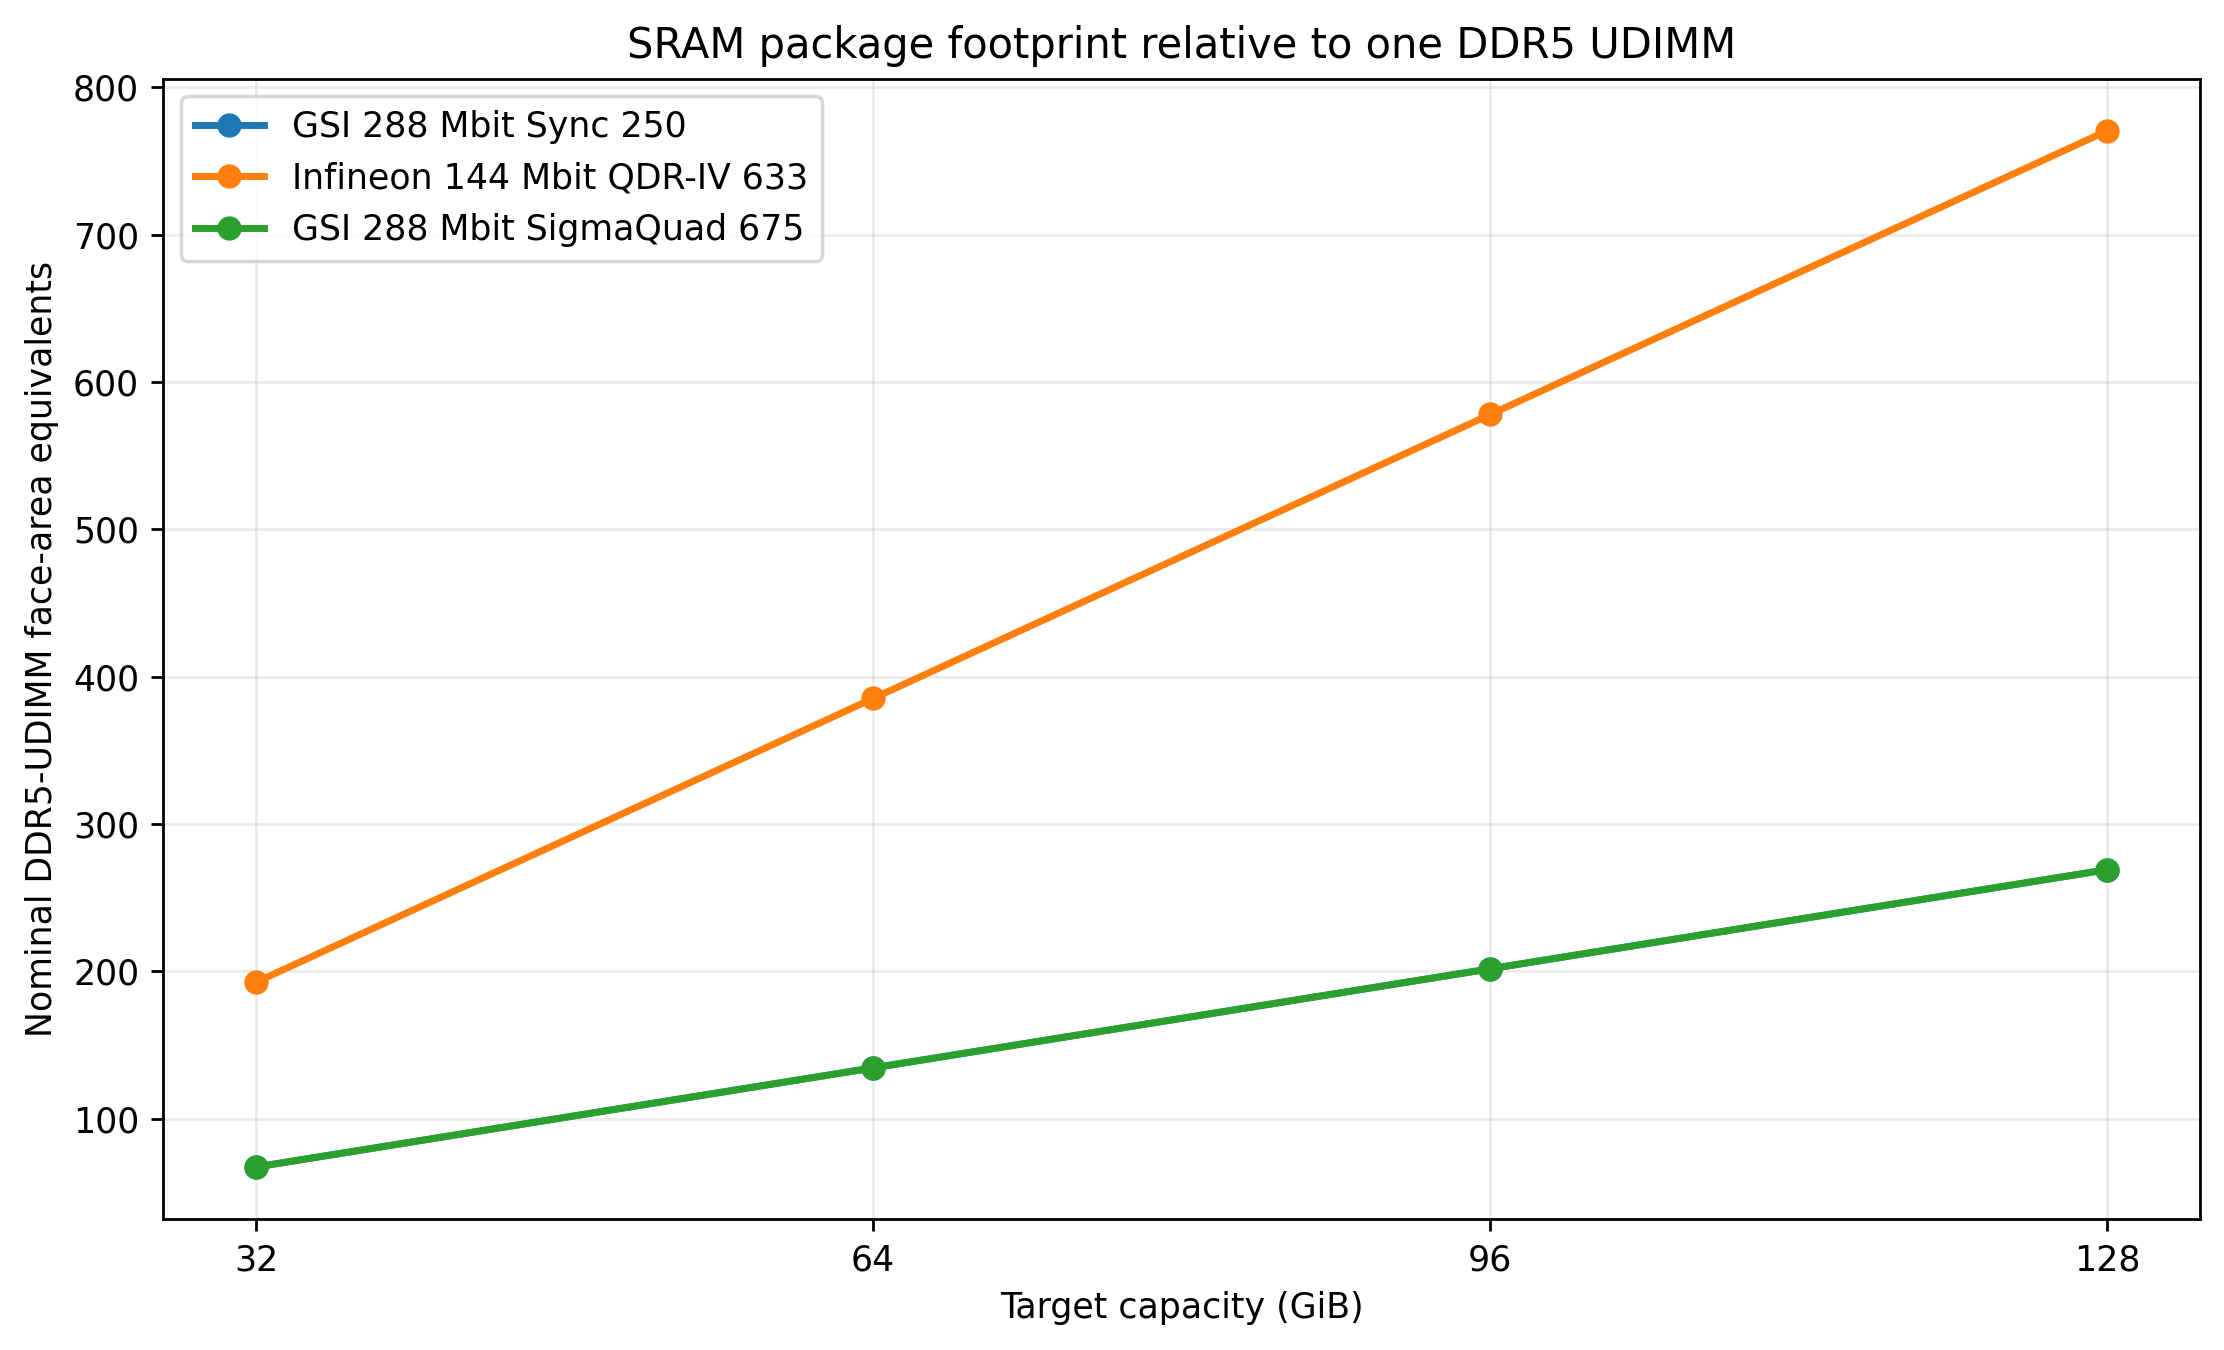

In [25]:
"""Plot idealized package area in DDR5-UDIMM face-area equivalents."""

fig, ax = plt.subplots(figsize=(9.0, 5.5))

for sram_name, group in sram_df.groupby("sram", sort=False):
    ax.plot(
        group["capacity_gib"],
        group["dimm_face_area_equivalents"],
        marker="o",
        linewidth=2,
        label=sram_name,
    )

ax.set_xlabel("Target capacity (GiB)")
ax.set_ylabel("Nominal DDR5-UDIMM face-area equivalents")
ax.set_title("SRAM package footprint relative to one DDR5 UDIMM")
ax.set_xticks(TARGET_CAPACITIES_GIB)
ax.legend()
fig.tight_layout()
plt.show()

## SRAM Cost Multiplier Relative to Matching DRAM

The 128 GiB DRAM baseline uses the displayed price of a four-module
DDR5-5600 CL40 kit that was out of stock in the snapshot, so its
multiplier should be read with that market-status caveat.

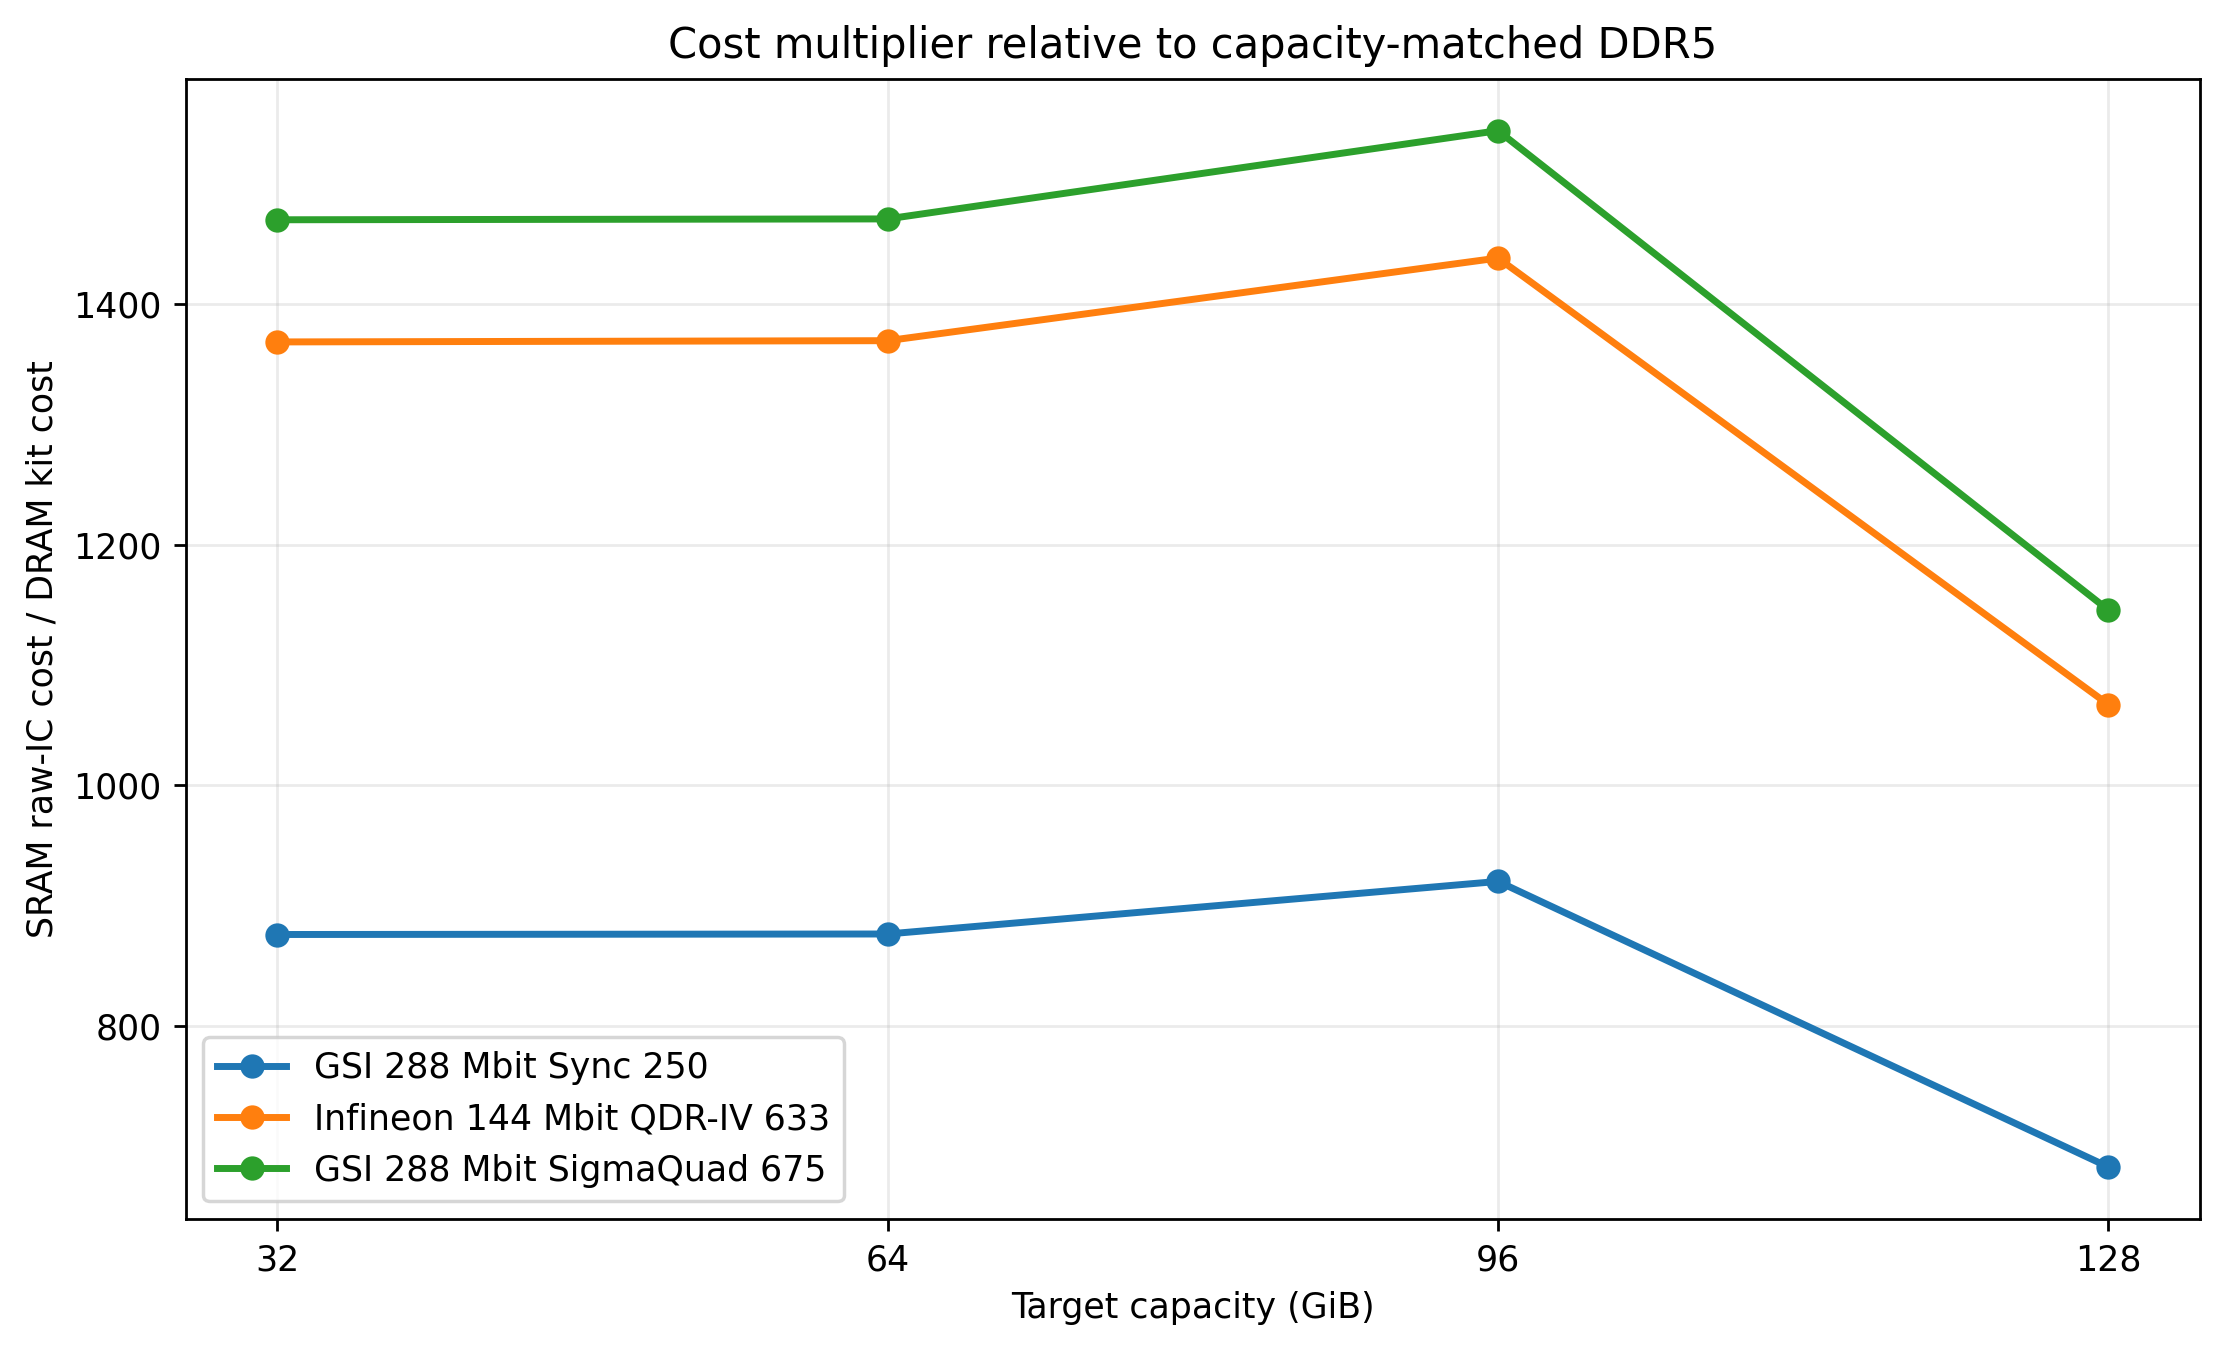

In [26]:
"""Plot SRAM raw-IC cost divided by matching DRAM retail cost."""

fig, ax = plt.subplots(figsize=(9.0, 5.5))

for sram_name, group in sram_df.groupby("sram", sort=False):
    ax.plot(
        group["capacity_gib"],
        group["cost_multiplier_vs_dram"],
        marker="o",
        linewidth=2,
        label=sram_name,
    )

ax.set_xlabel("Target capacity (GiB)")
ax.set_ylabel("SRAM raw-IC cost / DRAM kit cost")
ax.set_title("Cost multiplier relative to capacity-matched DDR5")
ax.set_xticks(TARGET_CAPACITIES_GIB)
ax.legend()
fig.tight_layout()
plt.show()

## Device-Level Read Timing

Latency and bandwidth describe different aspects of memory performance.
The SRAM parts have narrower package interfaces than a 64-bit DDR5
module, yet their random-access timing is shorter and more regular.

The DDR5 values below are timing-component estimates from CL40,
$t_{\mathrm{RCD}}=40$, and $t_{\mathrm{RP}}=40$. Full CPU-visible
memory latency also includes memory-controller, interconnect, queueing,
and protocol delays.

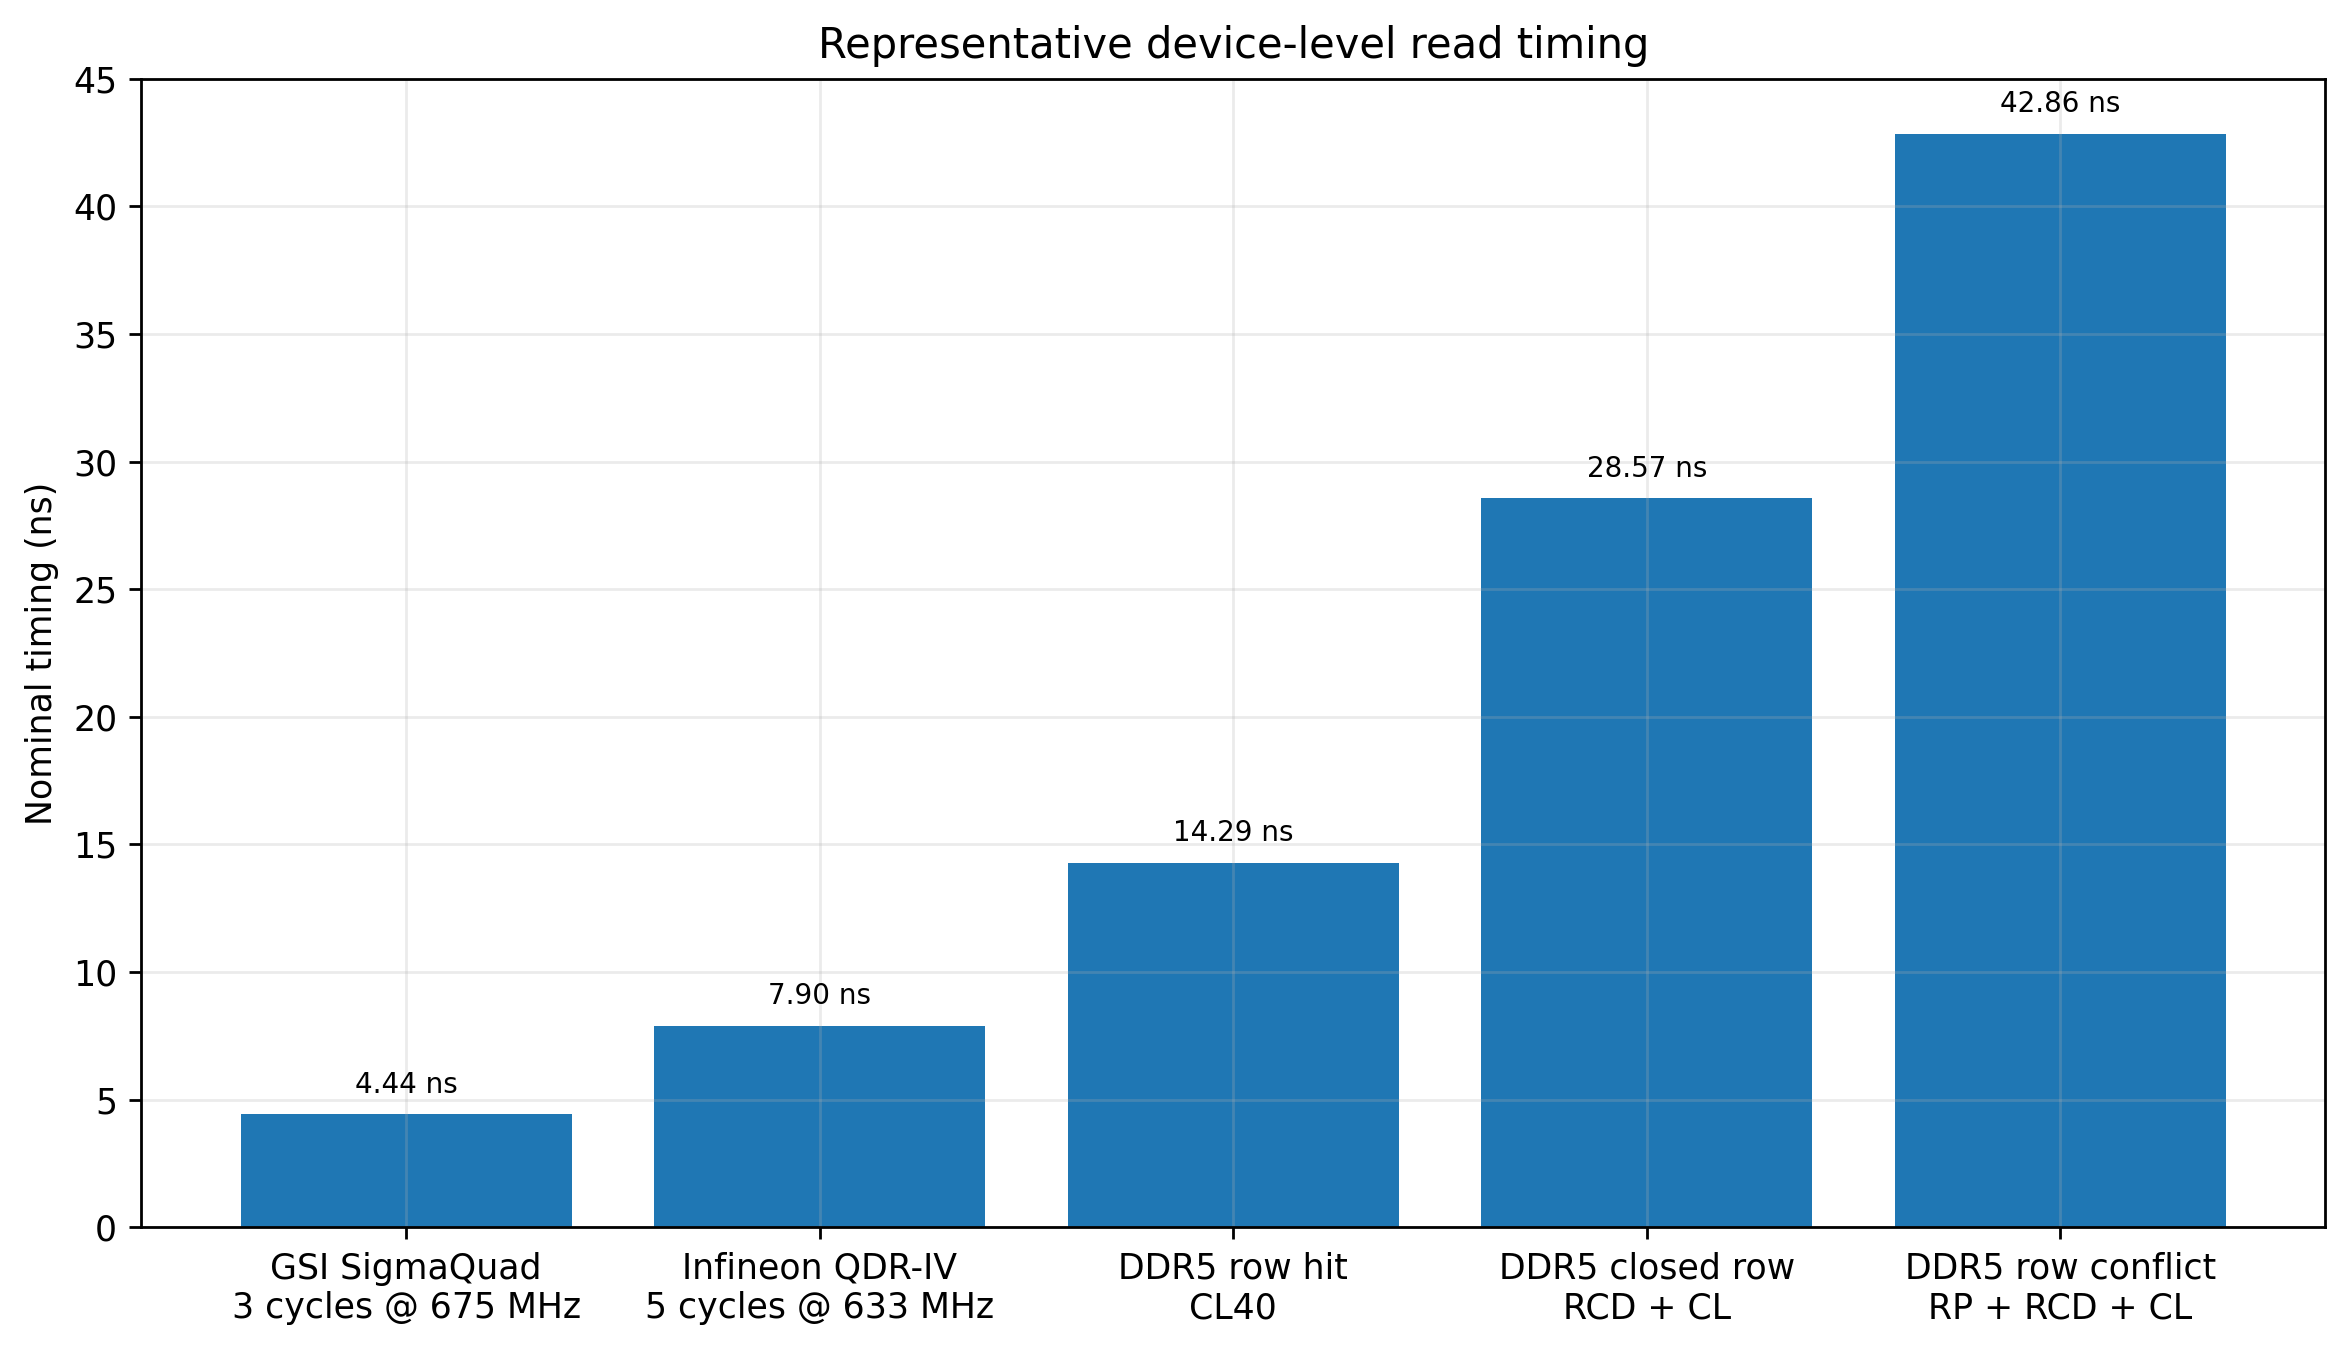

In [27]:
"""Plot representative device-level read timing."""

qdr_latency_ns = (
    5.0 * 1000.0 / 633.0
)
sigmaquad_latency_ns = (
    3.0 * 1000.0 / 675.0
)

latency_df = pd.DataFrame(
    {
        "case": [
            "GSI SigmaQuad\n3 cycles @ 675 MHz",
            "Infineon QDR-IV\n5 cycles @ 633 MHz",
            "DDR5 row hit\nCL40",
            "DDR5 closed row\nRCD + CL",
            "DDR5 row conflict\nRP + RCD + CL",
        ],
        "latency_ns": [
            sigmaquad_latency_ns,
            qdr_latency_ns,
            ddr5_cas_ns,
            ddr5_closed_row_ns,
            ddr5_row_conflict_ns,
        ],
    }
)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
bars = ax.bar(
    latency_df["case"],
    latency_df["latency_ns"],
)
ax.set_ylabel("Nominal timing (ns)")
ax.set_title("Representative device-level read timing")

for bar, value in zip(bars, latency_df["latency_ns"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        value + 0.6,
        f"{value:.2f} ns",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()
plt.show()

## Peak External Bandwidth per Package or Module

Interface width strongly shapes peak byte rate. This comparison uses one
SRAM package versus one 64-bit DDR5-5600 module interface.

The GSI SigmaQuad-IIIe x36 data sheet gives 97 Gb/s peak data bandwidth,
which equals $12.125$ GB/s. The QDR-IV x18 value is calculated from two
bidirectional DDR ports at 633 MHz. The 250 MHz standard synchronous
x36 SRAM uses a single-data-rate estimate.

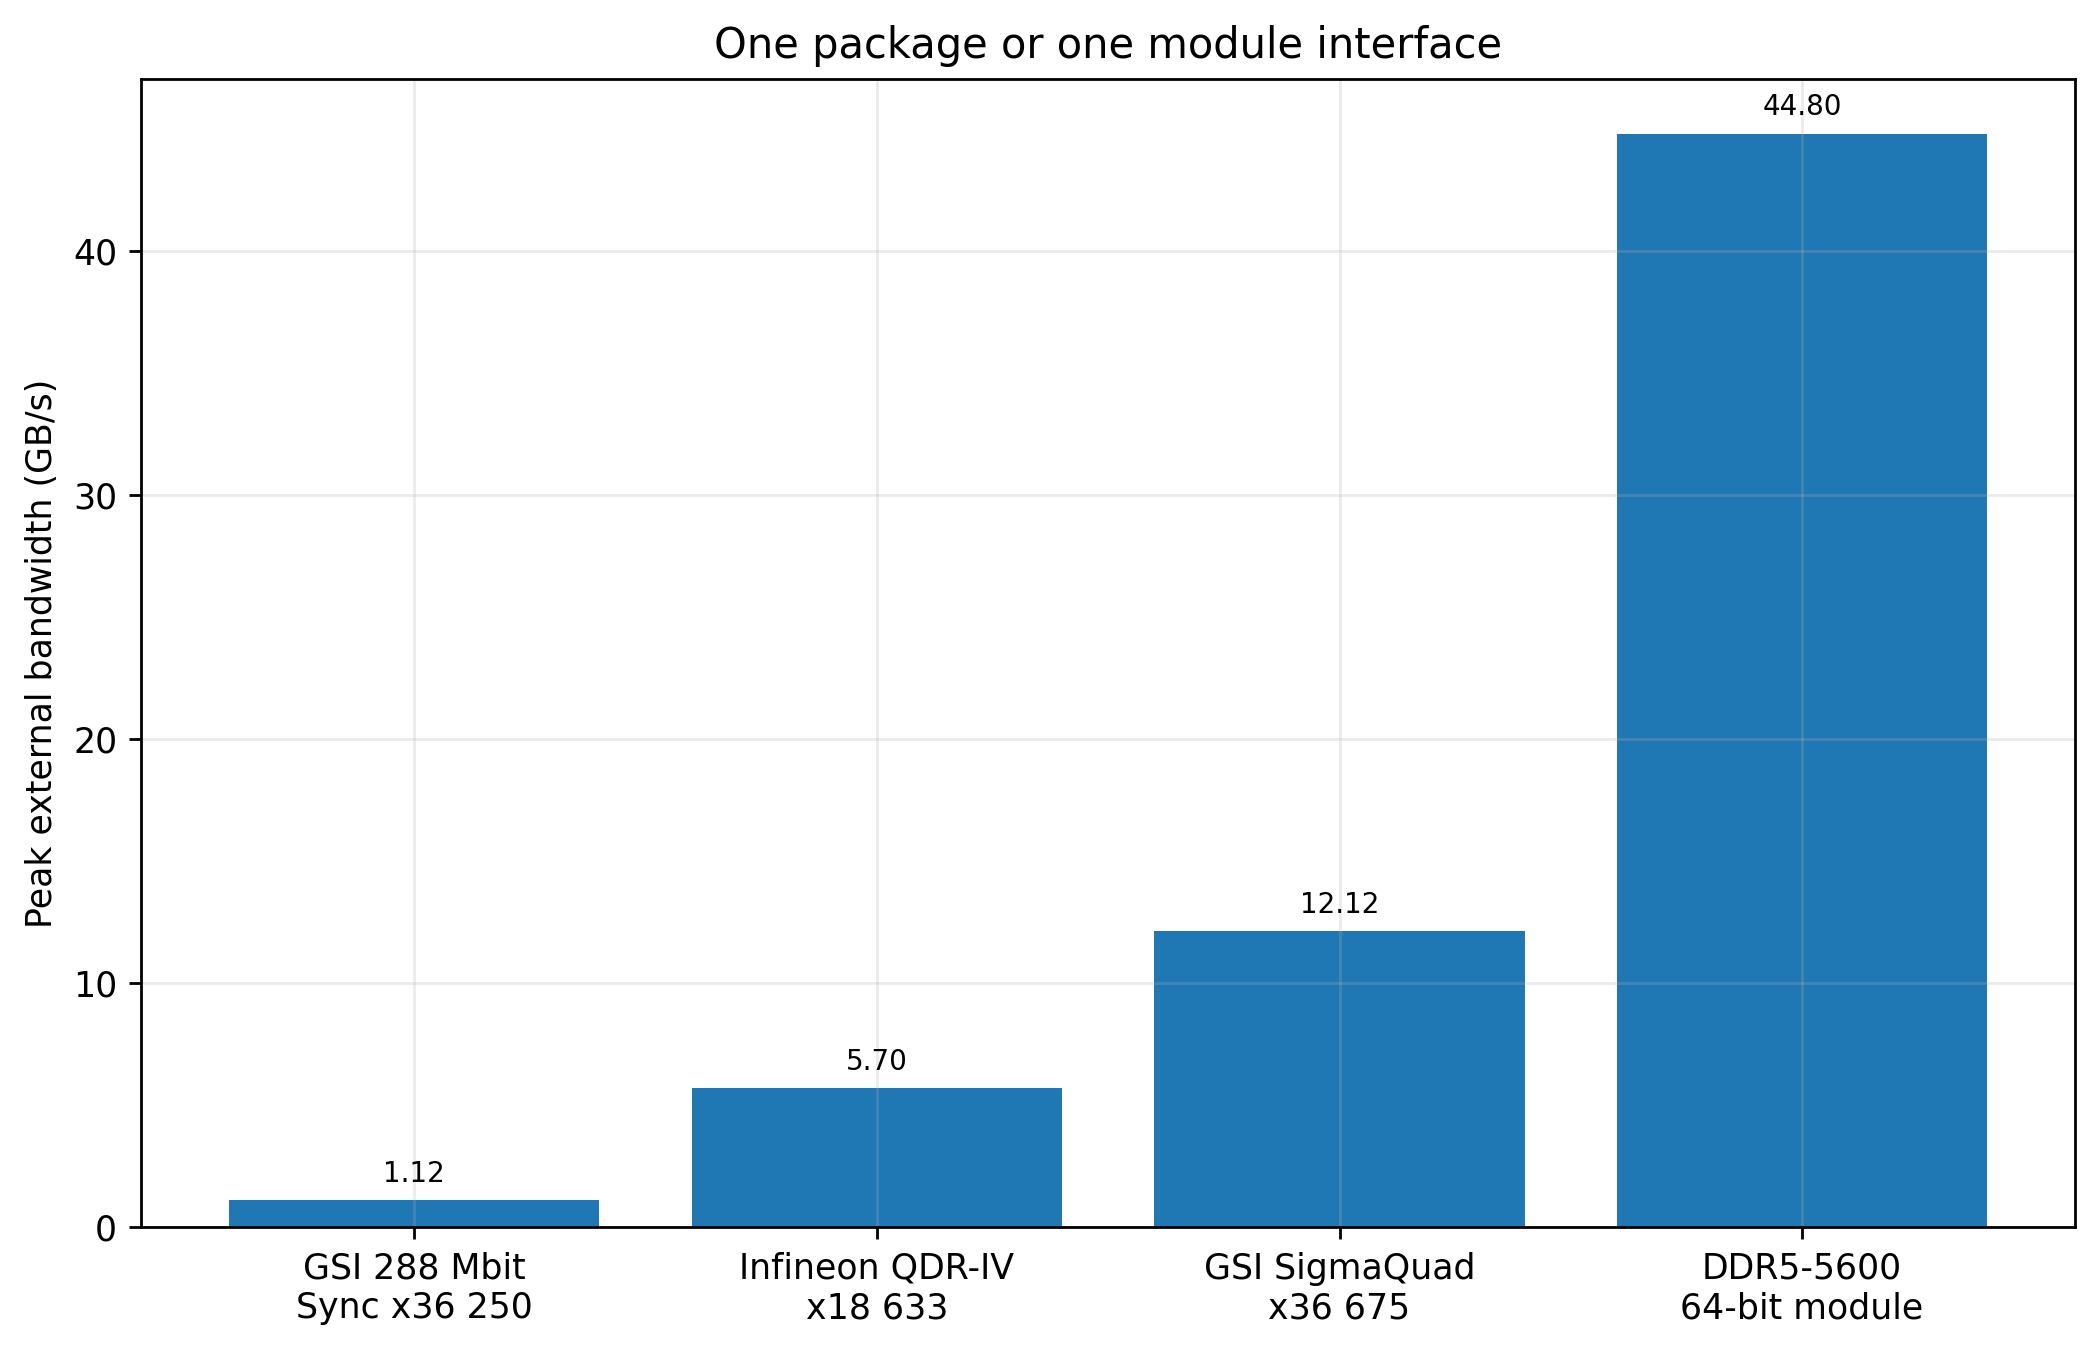

In [28]:
"""Plot peak package or module interface bandwidth."""

interface_bandwidth_df = pd.DataFrame(
    {
        "interface": [
            "GSI 288 Mbit\nSync x36 250",
            "Infineon QDR-IV\nx18 633",
            "GSI SigmaQuad\nx36 675",
            "DDR5-5600\n64-bit module",
        ],
        "bandwidth_gb_s": [
            1.125,
            5.697,
            97.0 / 8.0,
            ddr5_bandwidth_gb_s,
        ],
    }
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
bars = ax.bar(
    interface_bandwidth_df["interface"],
    interface_bandwidth_df["bandwidth_gb_s"],
)
ax.set_ylabel("Peak external bandwidth (GB/s)")
ax.set_title("One package or one module interface")

for bar, value in zip(
    bars,
    interface_bandwidth_df["bandwidth_gb_s"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        value + 0.5,
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

fig.tight_layout()
plt.show()

## Pin-Level Aggregate SRAM Bandwidth

Summing every package's local interface produces a mathematical upper
bound on exposed pin bandwidth. A real controller, connector, PCB,
package substrate, and processor cannot consume this entire sum as one
flat memory channel. The curve is still informative because it shows how
much I/O fabric a workstation-scale SRAM implementation would create.

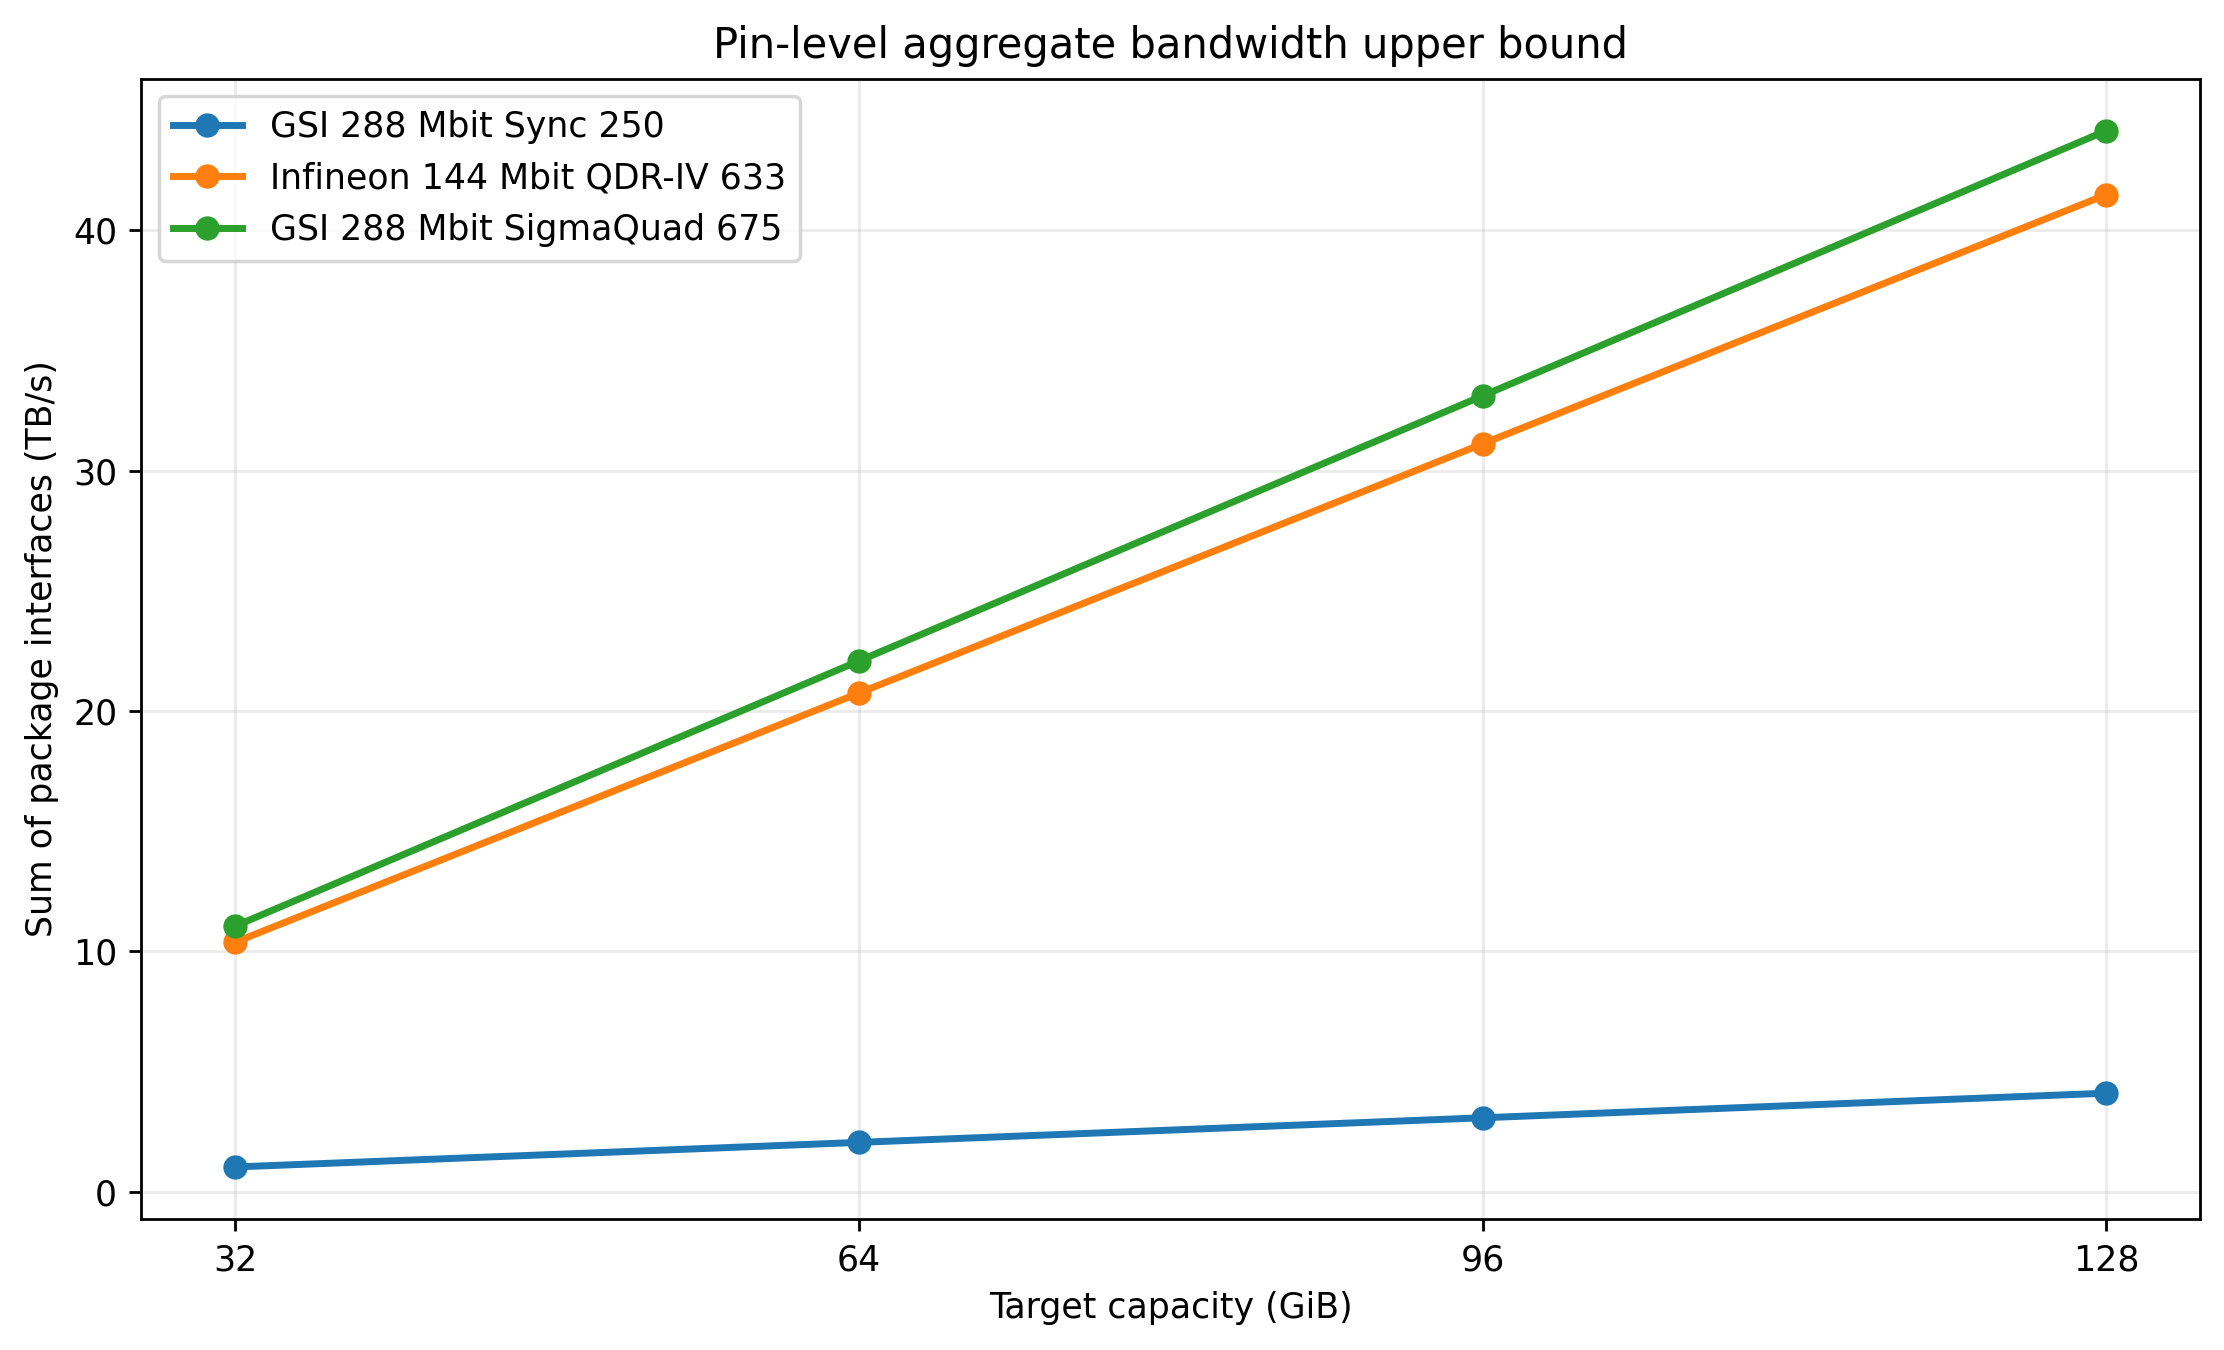

In [29]:
"""Plot the unconstrained sum of package-level SRAM bandwidth."""

fig, ax = plt.subplots(figsize=(9.0, 5.5))

for sram_name, group in sram_df.groupby("sram", sort=False):
    ax.plot(
        group["capacity_gib"],
        group["pin_level_sum_bandwidth_tb_s"],
        marker="o",
        linewidth=2,
        label=sram_name,
    )

ax.set_xlabel("Target capacity (GiB)")
ax.set_ylabel("Sum of package interfaces (TB/s)")
ax.set_title("Pin-level aggregate bandwidth upper bound")
ax.set_xticks(TARGET_CAPACITIES_GIB)
ax.legend()
fig.tight_layout()
plt.show()

## SRAM Core-Power Scaling

The Infineon QDR-IV data sheet gives a typical $I_{\mathrm{DD}}$ of
$1.655$ A for the 633 MHz x18 device at $1.3$ V. Its maximum listed core
current is $2.4$ A; using $1.34$ V gives a conservative core-only upper
estimate.

The GSI SigmaQuad-IIIe x36 data sheet lists an operating current of
$1.780$ A at 675 MHz and a nominal $1.3$ V core supply.

These estimates cover core supply power only. I/O termination, FPGA or
ASIC memory controllers, regulators, clocks, fans, and conversion losses
increase subsystem power.

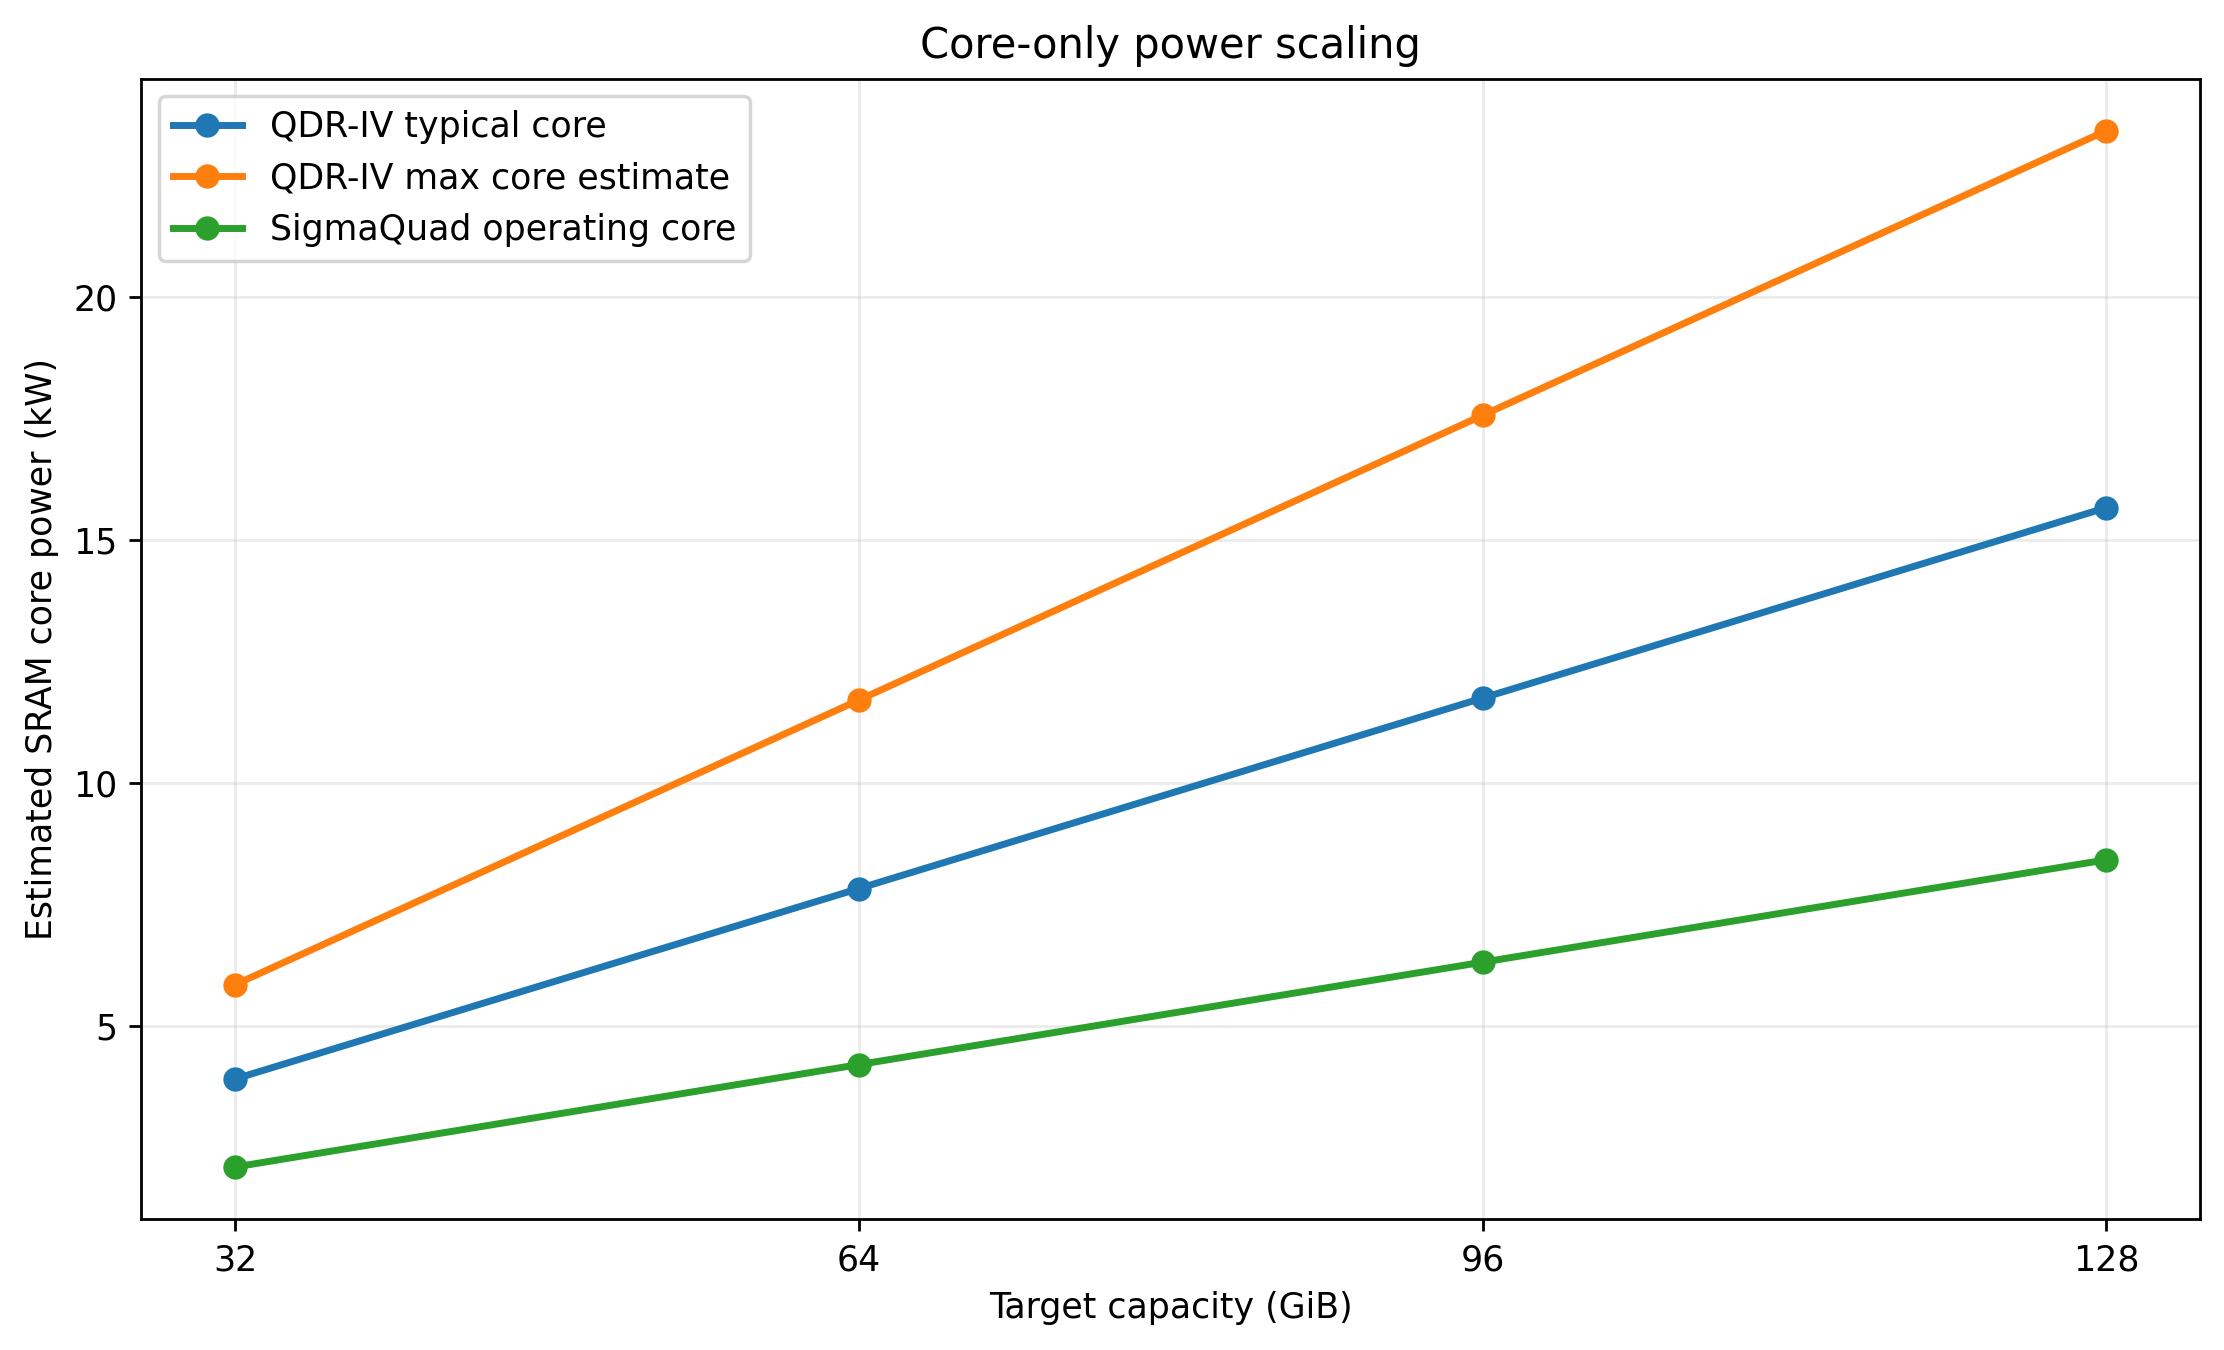

In [30]:
"""Plot core-only SRAM power scaling."""

power_rows: list[dict[str, float | str]] = []

for capacity_gib in TARGET_CAPACITIES_GIB:
    qdr_count = package_count(float(capacity_gib), 144.0)
    sigma_count = package_count(float(capacity_gib), 288.0)

    power_rows.extend(
        [
            {
                "capacity_gib": int(capacity_gib),
                "case": "QDR-IV typical core",
                "power_kw": (
                    qdr_count * 1.655 * 1.3 / 1000.0
                ),
            },
            {
                "capacity_gib": int(capacity_gib),
                "case": "QDR-IV max core estimate",
                "power_kw": (
                    qdr_count * 2.4 * 1.34 / 1000.0
                ),
            },
            {
                "capacity_gib": int(capacity_gib),
                "case": "SigmaQuad operating core",
                "power_kw": (
                    sigma_count * 1.780 * 1.3 / 1000.0
                ),
            },
        ]
    )

power_df = pd.DataFrame(power_rows)

fig, ax = plt.subplots(figsize=(9.0, 5.5))

for case_name, group in power_df.groupby("case", sort=False):
    ax.plot(
        group["capacity_gib"],
        group["power_kw"],
        marker="o",
        linewidth=2,
        label=case_name,
    )

ax.set_xlabel("Target capacity (GiB)")
ax.set_ylabel("Estimated SRAM core power (kW)")
ax.set_title("Core-only power scaling")
ax.set_xticks(TARGET_CAPACITIES_GIB)
ax.legend()
fig.tight_layout()
plt.show()

## Focused 64, 96, and 128 GiB Results

The density-oriented 288 Mbit, 250 MHz SRAM produces the lowest raw IC
cost among the three sampled SRAM choices. The 675 MHz SigmaQuad case
trades a larger component budget for shorter read latency and a much
wider package data path. The 144 Mbit QDR-IV case doubles the package
count relative to 288 Mbit devices.

The final table rounds financial figures to the nearest dollar and area
to three decimal places.

In [31]:
"""Display the requested 64, 96, and 128 GiB summary."""

focus_capacities = [64, 96, 128]

focus_df = (
    sram_df[sram_df["capacity_gib"].isin(focus_capacities)]
    [
        [
            "capacity_gib",
            "sram",
            "package_count",
            "raw_ic_cost_usd",
            "cost_multiplier_vs_dram",
            "ideal_package_area_m2",
            "read_latency_ns",
            "per_package_bandwidth_gb_s",
            "estimated_core_power_kw",
        ]
    ]
    .copy()
)

display(
    focus_df.sort_values(
        ["capacity_gib", "raw_ic_cost_usd"]
    ).round(
        {
            "raw_ic_cost_usd": 0,
            "cost_multiplier_vs_dram": 1,
            "ideal_package_area_m2": 3,
            "read_latency_ns": 3,
            "per_package_bandwidth_gb_s": 3,
            "estimated_core_power_kw": 3,
        }
    )
)

,capacity_gib,sram,package_count,raw_ic_cost_usd,cost_multiplier_vs_dram,ideal_package_area_m2,read_latency_ns,per_package_bandwidth_gb_s,estimated_core_power_kw
1,64,GSI 288 Mbit Sync 250,1821,838498.0,876.2,0.561,NaN,1.125,NaN
5,64,Infineon 144 Mbit QDR-IV 633,3641,1310836.0,1369.7,1.606,7.899,5.697,7.834
9,64,GSI 288 Mbit SigmaQuad 675,1821,1407779.0,1471.0,0.561,4.444,12.125,4.214
2,96,GSI 288 Mbit Sync 250,2731,1257516.0,919.9,0.841,NaN,1.125,NaN
6,96,Infineon 144 Mbit QDR-IV 633,5462,1966435.0,1438.5,2.409,7.899,5.697,11.751
10,96,GSI 288 Mbit SigmaQuad 675,2731,2111281.0,1544.5,0.841,4.444,12.125,6.320
3,128,GSI 288 Mbit Sync 250,3641,1676535.0,682.4,1.121,NaN,1.125,NaN
7,128,Infineon 144 Mbit QDR-IV 633,7282,2621673.0,1067.0,3.211,7.899,5.697,15.667
11,128,GSI 288 Mbit SigmaQuad 675,3641,2814784.0,1145.6,1.121,4.444,12.125,8.425


In [32]:
"""Export normalized tables for later engineering work."""

if EXPORT_CSV:
    EXPORT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    dram_path = EXPORT_DIRECTORY / "dram_aug2026.csv"
    sram_parts_path = EXPORT_DIRECTORY / "sram_parts_aug2026.csv"
    scaled_path = EXPORT_DIRECTORY / "sram_scaled_32_128gib_aug2026.csv"

    dram_df.to_csv(dram_path, index=False)
    sram_parts_df.to_csv(sram_parts_path, index=False)
    sram_df.to_csv(scaled_path, index=False)

    print("Exported:")
    print(dram_path)
    print(sram_parts_path)
    print(scaled_path)

Exported:
/content/dram_aug2026.csv
/content/sram_parts_aug2026.csv
/content/sram_scaled_32_128gib_aug2026.csv


## Engineering Interpretation

```text
32–128 GiB volatile-memory design space
│
├── Commodity DDR5 DRAM
│   ├── ≈ $14–$19 per GiB in the sampled retail kits
│   ├── 44.8 GB/s per 64-bit DDR5-5600 module interface
│   ├── Row activation, precharge, and refresh behavior
│   └── Practical workstation and server capacities
│
└── Discrete SRAM
    │
    ├── Density branch
    │   ├── 144 Mbit → 18 MiB/package
    │   └── 288 Mbit → 36 MiB/package
    │
    ├── Performance branch
    │   ├── Standard sync SRAM
    │   ├── QDR-IV
    │   └── SigmaQuad-IIIe
    │
    ├── Scaling consequences
    │   ├── Hundreds to thousands of packages
    │   ├── ≈ 0.28–3.21 m² package-only area across sampled cases
    │   ├── Multi-kilowatt core-power regimes
    │   └── Raw IC costs reaching ≈ $0.4–$2.8 million
    │
    └── Architectural role
        ├── Excellent for caches, packet memories, counters, lookup tables
        └── Poor economic fit for commodity bulk main memory
```

The physical and electrical scaling helps explain the historical memory
hierarchy. SRAM is concentrated close to processors where latency and
random transaction rate have exceptional value per stored bit. DRAM
occupies the bulk-memory layer where density and cost per bit dominate.

The August 2026 source values used here:

| Capacity | 288 Mbit Sync SRAM, 250 MHz | 144 Mbit QDR-IV, 633 MHz | 288 Mbit SigmaQuad, 675 MHz |
| :---: | ---: | ---: | ---: |
| 32 GiB | about \$419k | about \$656k | about \$704k |
| 64 GiB | about \$838k | about \$1.31M | about \$1.41M |
| 96 GiB | about \$1.26M | about \$1.97M | about \$2.11M |
| 128 GiB | about \$1.68M | about \$2.62M | about \$2.81M |

For the density-oriented 288 Mbit part, 64, 96, and 128 GiB require
approximately **1,821**, **2,731**, and **3,641** packages. The 144 Mbit
QDR-IV part requires approximately **3,641**, **5,462**, and **7,282**
packages for the same capacities.

At 128 GiB, the package rectangles alone occupy about **1.12 m²** for
either 288 Mbit GSI case and about **3.21 m²** for the 144 Mbit QDR-IV
case. The corresponding memory subsystem would therefore be a
multi-board assembly rather than a DIMM-scale object.

## References

**DRAM retail baselines**

1. Corsair VENGEANCE 32 GB, $1\times32$ GB, DDR5-5600 CL40,
   $\$478.99$  
   https://www.corsair.com/us/en/p/memory/cmk32gx5m1b5600c40/
2. Corsair VENGEANCE 64 GB, $2\times32$ GB, DDR5-5600 CL40,
   $\$956.99$  
   https://www.corsair.com/us/en/p/memory/cmk64gx5m2d5600z40/
3. Corsair VENGEANCE 96 GB, $2\times48$ GB, DDR5-5600 CL40,
   $\$1,366.99$  
   https://www.corsair.com/us/en/p/memory/cmk96gx5m2b5600c40/
4. Corsair VENGEANCE 128 GB, $4\times32$ GB, DDR5-5600 CL40,
   displayed at $\$2,456.99$ and out of stock in the snapshot  
   https://www.corsair.com/us/en/p/memory/cmk128gx5m4b5600c40/
5. GSI GS8256436GB-250I, 288 Mbit, $8\mathrm{M}\times36$,
   250 MHz, 119-FPBGA, $22\times14$ mm, DigiKey listed
   $\$460.46$ at the 10-unit tier  
   https://www.digikey.com/en/products/detail/gsi-technology-inc/GS8256436GB-250I/12090596
6. Infineon CY7C4121KV13-633FCXI, 144 Mbit,
   $8\mathrm{M}\times18$, QDR-IV HP, 633 MHz, five-cycle read
   latency, $21\times21$ mm FCBGA. The August 2026 DigiKey
   category snapshot listed $\$360.021$ at the 120-unit tier.  
   https://www.infineon.com/part/CY7C4121KV13-633FCXI  
   https://www.digikey.com/en/products/filter/memory/memory/361-bbga-fcbga/774
7. GSI GS82583ED36GK-675I, 288 Mbit,
   $8\mathrm{M}\times36$, SigmaQuad-IIIe B4, 675 MHz,
   three-cycle read latency, 97 Gb/s peak package bandwidth,
   $22\times14$ mm BGA, DigiKey listed $\$773.08$ at the
   10-unit tier.  
   https://www.digikey.com/en/products/filter/memory/memory/260-bga/774  
   https://gsitechnology.com/wp-content/uploads/sites/default/files/datasheets/SigmaQuadDDR/288Mb/82583EDxx.pdf
8. JEDEC DDR5 UDIMM nominal dimensions are
   $133.35\times31.25$ mm, giving a PCB face area of about
   $4,167\ \mathrm{mm^2}$.